
Omar Rodríguez Montiel - A01750836

[Dataset Diabetes - Kaggle](https://www.kaggle.com/datasets/nanditapore/healthcare-diabetes)

# Dependencias

In [ ]:
import os

# Manejo de datos
import pandas as pd
import numpy as np

# Visualización
import matplotlib.pyplot as plt
import seaborn as sns

# Modelos de aprendizaje
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix, silhouette_score
from sklearn.preprocessing import MinMaxScaler, StandardScaler

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture

# Herramientas extra
os.system('pip install kneed')
from kneed import KneeLocator
from itertools import combinations
from tqdm.autonotebook import tqdm

<ipython-input-1-b8cc0dcd66cb>:25: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


# Importar datos

In [ ]:
df = pd.read_csv('/content/Healthcare-Diabetes.csv', index_col='Id')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Id,,,,,,,,,
1,6,148,72,35,0,33.6,0.627,50,1
2,1,85,66,29,0,26.6,0.351,31,0
3,8,183,64,0,0,23.3,0.672,32,1
4,1,89,66,23,94,28.1,0.167,21,0
5,0,137,40,35,168,43.1,2.288,33,1


# Exploración de los datos

<Axes: ylabel='Frequency'>

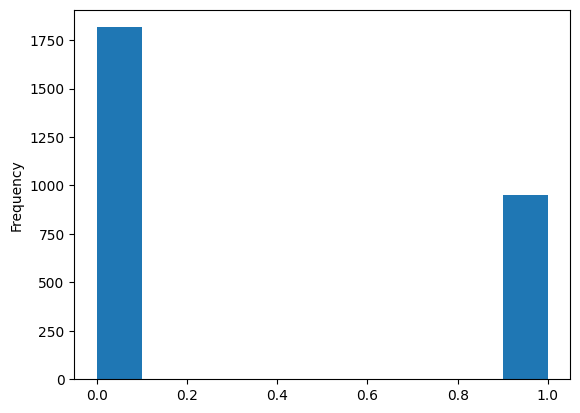

In [ ]:
df.Outcome.plot.hist()

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Pregnancies,2768.0,3.742775,3.323801,0.000,1.000,3.000,6.000,17.00
Glucose,2768.0,121.102601,32.036508,0.000,99.000,117.000,141.000,199.00
BloodPressure,2768.0,69.134393,19.231438,0.000,62.000,72.000,80.000,122.00
SkinThickness,2768.0,20.824422,16.059596,0.000,0.000,23.000,32.000,110.00
Insulin,2768.0,80.127890,112.301933,0.000,0.000,37.000,130.000,846.00
BMI,2768.0,32.137392,8.076127,0.000,27.300,32.200,36.625,80.60
DiabetesPedigreeFunction,2768.0,0.471193,0.325669,0.078,0.244,0.375,0.624,2.42
Age,2768.0,33.132225,11.777230,21.000,24.000,29.000,40.000,81.00
Outcome,2768.0,0.343931,0.475104,0.000,0.000,0.000,1.000,1.00


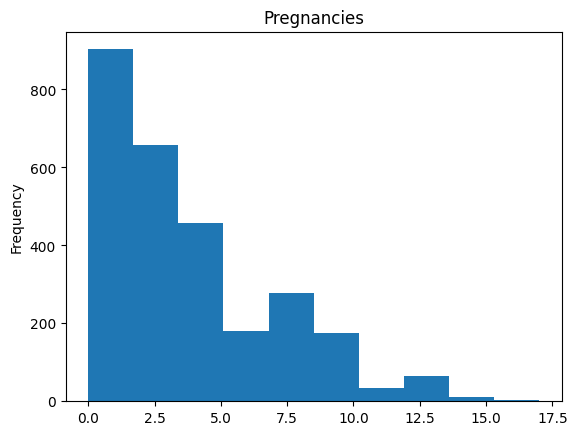

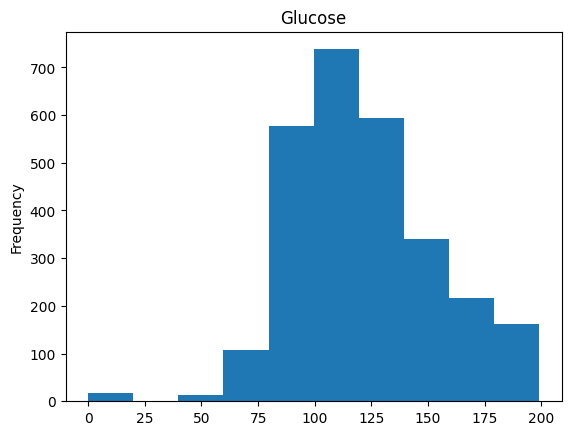

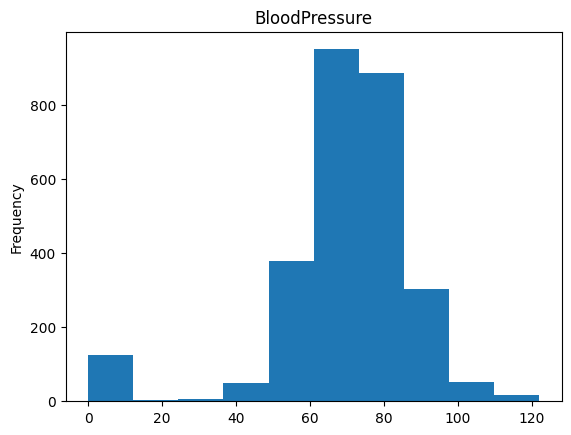

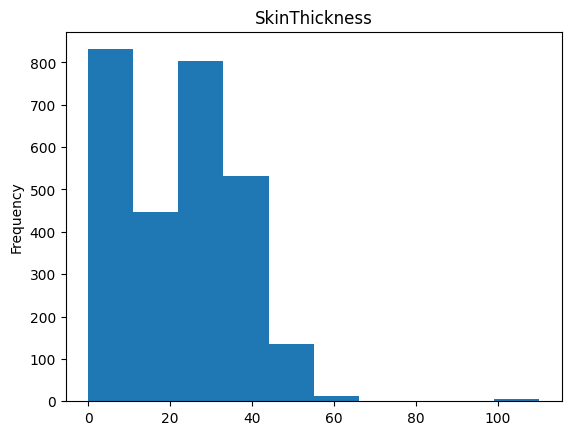

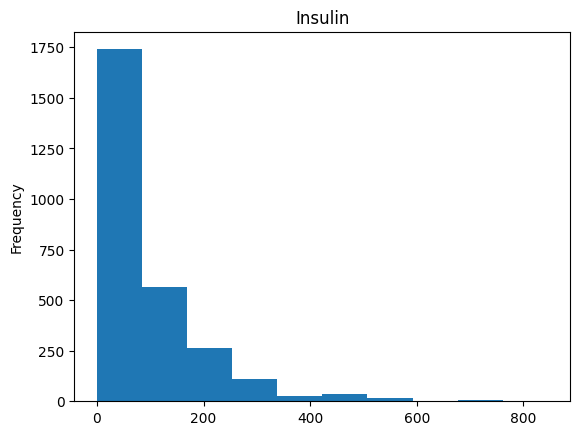

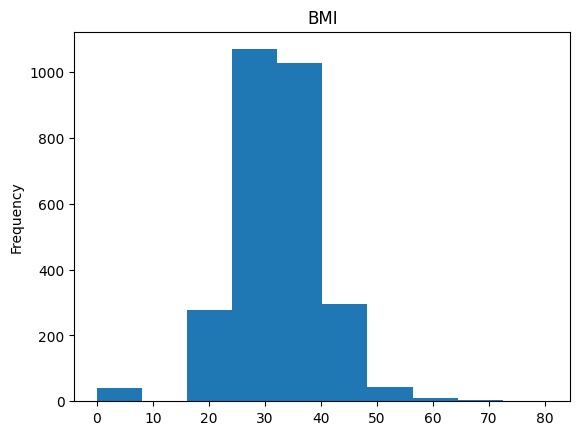

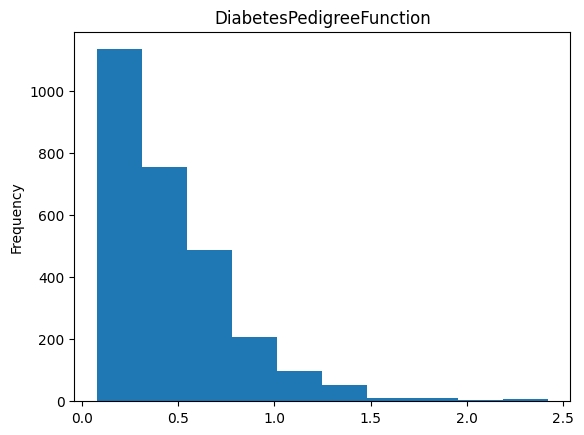

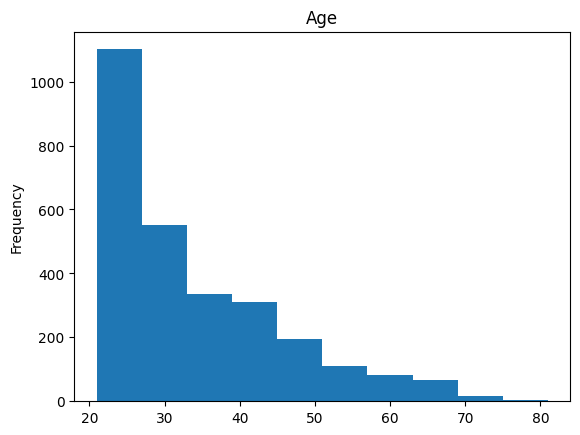

In [ ]:
for col in df.columns[:-1]:
    plt.title(col)
    df[col].plot.hist() #plotting the histogram with Pandas
    plt.show()

# Pre-procesamiento

In [ ]:
numeric_cols = [col for col in df.columns if df[col].nunique() > 2]
categoric_cols = [col for col in df.columns if col not in numeric_cols]

norm = df.copy()
scaled = df.copy()

mms = MinMaxScaler()
ss = StandardScaler()

for col in numeric_cols:
    norm[col] = mms.fit_transform(norm[[col]])
    scaled[col] = ss.fit_transform(scaled[[col]])

display(norm.describe().T)
display(scaled.describe().T)

,count,mean,std,min,25%,50%,75%,max
Pregnancies,2768.0,0.220163,0.195518,0.0,0.058824,0.176471,0.352941,1.0
Glucose,2768.0,0.608556,0.160987,0.0,0.497487,0.587940,0.708543,1.0
BloodPressure,2768.0,0.566675,0.157635,0.0,0.508197,0.590164,0.655738,1.0
SkinThickness,2768.0,0.189313,0.145996,0.0,0.000000,0.209091,0.290909,1.0
Insulin,2768.0,0.094714,0.132745,0.0,0.000000,0.043735,0.153664,1.0
BMI,2768.0,0.398727,0.100200,0.0,0.338710,0.399504,0.454404,1.0
DiabetesPedigreeFunction,2768.0,0.167888,0.139056,0.0,0.070880,0.126815,0.233134,1.0
Age,2768.0,0.202204,0.196287,0.0,0.050000,0.133333,0.316667,1.0
Outcome,2768.0,0.343931,0.475104,0.0,0.000000,0.000000,1.000000,1.0


,count,mean,std,min,25%,50%,75%,max
Pregnancies,2768.0,2.566990e-18,1.000181,-1.126256,-0.825341,-0.223512,0.679232,3.989294
Glucose,2768.0,-1.360505e-16,1.000181,-3.780827,-0.690044,-0.128083,0.621197,2.431959
BloodPressure,2768.0,2.310291e-17,1.000181,-3.595513,-0.371043,0.149033,0.565094,2.749413
SkinThickness,2768.0,-7.700969e-17,1.000181,-1.296931,-1.296931,0.135494,0.696007,5.553794
Insulin,2768.0,-7.700969e-18,1.000181,-0.713633,-0.713633,-0.384105,0.444170,6.820991
BMI,2768.0,-3.106057e-16,1.000181,-3.980026,-0.599082,0.007754,0.555764,6.001808
DiabetesPedigreeFunction,2768.0,5.262329e-17,1.000181,-1.207557,-0.697744,-0.295423,0.469296,5.985097
Age,2768.0,1.562655e-16,1.000181,-1.030329,-0.775554,-0.350929,0.583245,4.065168
Outcome,2768.0,3.439306e-01,0.475104,0.000000,0.000000,0.000000,1.000000,1.000000


<Axes: >

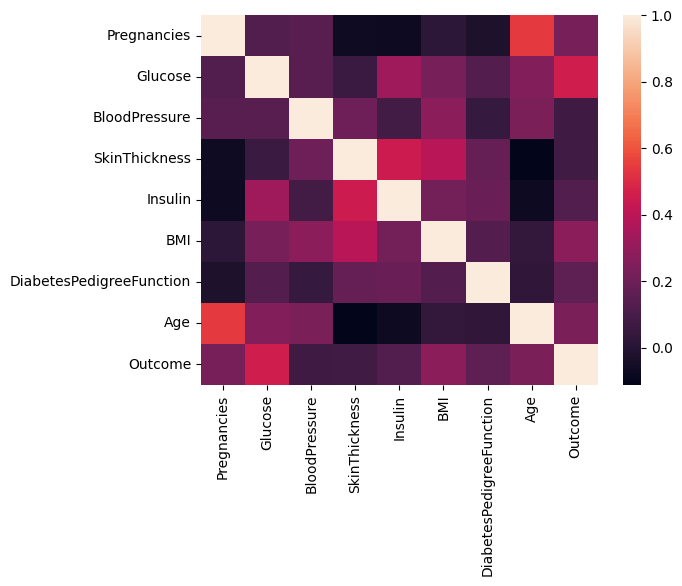

In [ ]:
sns.heatmap(df.corr())

# Separación de los datos

In [ ]:
X, y = norm.iloc[:, :-1], norm.iloc[:, -1]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
evaluate = lambda y_true, y_pred, label='': print(f'{label}\t Accuracy = {accuracy_score(y_true, y_pred)*100:.2f}%    \t F1 Score = {f1_score(y_true, y_pred)*100:.2f}%')

In [ ]:
def visualize_metrics(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    print(classification_report(y_true,y_pred))

    sns.heatmap(cm, annot=True, fmt='d').set_title('Confusion matrix')

# Aprendizaje supervisado

### **Árbol de decisión**
(visto en clase)

#### Entrenamiento

In [ ]:
param_grid = {
    'criterion': ['gini', 'entropy', 'log_loss'],
    'max_depth': list(range(3, 16))
}

# Buscar mejor configuración de hiperparámetros y selección de datos
grid = GridSearchCV(DecisionTreeClassifier(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train, y_train)
clf = grid.best_estimator_

y_pred_train = clf.predict(X_train)
y_pred = clf.predict(X_test)

evaluate(y_train, y_pred_train, 'Train data --')
evaluate(y_test, y_pred, 'Test data --')

Train data --	 Accuracy = 100.00%    	 F1 Score = 100.00%
Test data --	 Accuracy = 98.38%    	 F1 Score = 97.56%


#### Visualización

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1449
           1       1.00      1.00      1.00       765

    accuracy                           1.00      2214
   macro avg       1.00      1.00      1.00      2214
weighted avg       1.00      1.00      1.00      2214



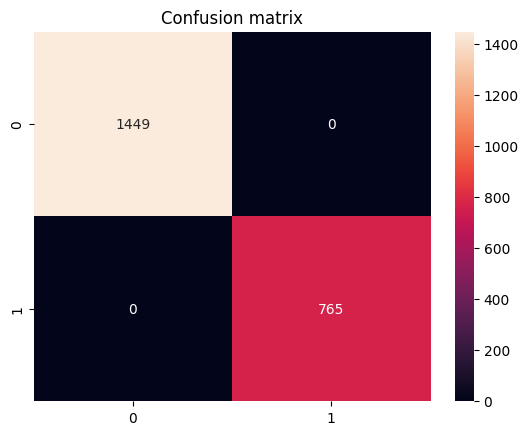

In [ ]:
visualize_metrics(y_train, y_pred_train) # Matriz de confusión de datos de entrenamiento

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       367
           1       0.99      0.96      0.98       187

    accuracy                           0.98       554
   macro avg       0.99      0.98      0.98       554
weighted avg       0.98      0.98      0.98       554



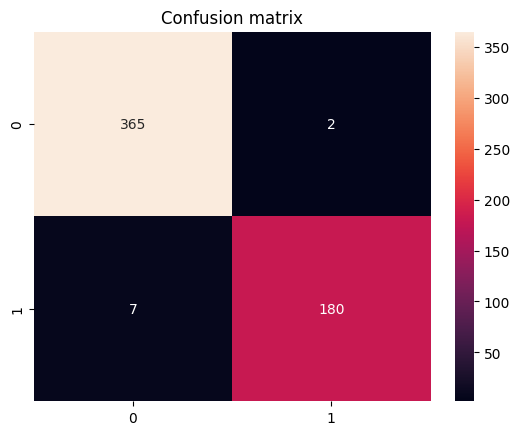

In [ ]:
visualize_metrics(y_test, y_pred) # Matriz de confusión de datos de prueba

### **Bosques Aleatorios**
(no visto en clase)

#### Entrenamiento

In [ ]:
rf = RandomForestClassifier(criterion=clf.get_params()['criterion'], max_depth=clf.get_params()['max_depth'], n_estimators=300)
rf.fit(X_train, y_train)

y_pred_train = rf.predict(X_train)
y_pred = rf.predict(X_test)

evaluate(y_train, y_pred_train, 'Train data --')
evaluate(y_test, y_pred, 'Test data --')

Train data --	 Accuracy = 100.00%    	 F1 Score = 100.00%
Test data --	 Accuracy = 98.19%    	 F1 Score = 97.30%


#### Visualización

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1449
           1       1.00      1.00      1.00       765

    accuracy                           1.00      2214
   macro avg       1.00      1.00      1.00      2214
weighted avg       1.00      1.00      1.00      2214



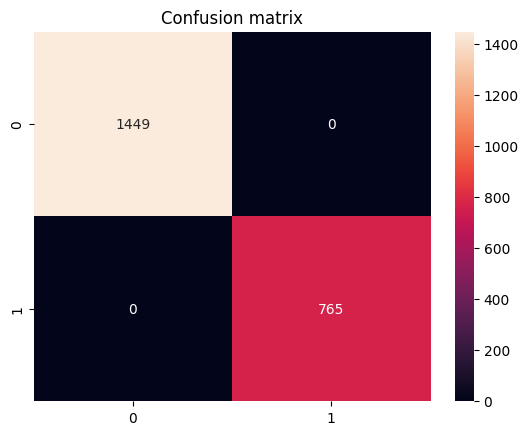

In [ ]:
visualize_metrics(y_train, y_pred_train) # Matriz de confusión de datos de entrenamiento

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       367
           1       0.98      0.96      0.97       187

    accuracy                           0.98       554
   macro avg       0.98      0.98      0.98       554
weighted avg       0.98      0.98      0.98       554



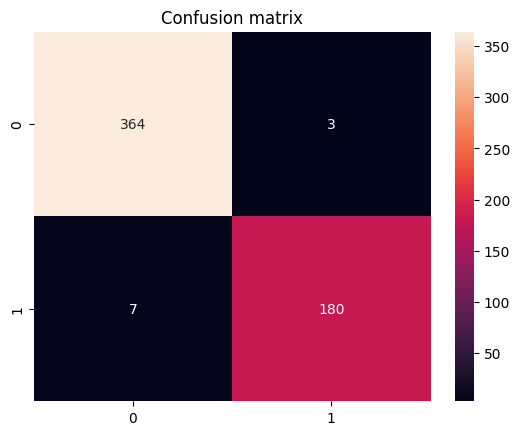

In [ ]:
visualize_metrics(y_test, y_pred) # Matriz de confusión de datos de prueba

# Aprendizaje no supervisado

### Exploración de los datos

In [ ]:
def plot_tsne(X, y):
    from sklearn.manifold import TSNE
    tsne = TSNE(perplexity=5, n_components=2, init="pca", n_iter=5000)

    coords = tsne.fit_transform(X)

    X_, y_ = list(zip(*coords))
    plt.figure(figsize=(10, 6))
    p = sns.scatterplot(x=X_, y=y_)
    plt.grid(True)
    plt.show()

    return coords

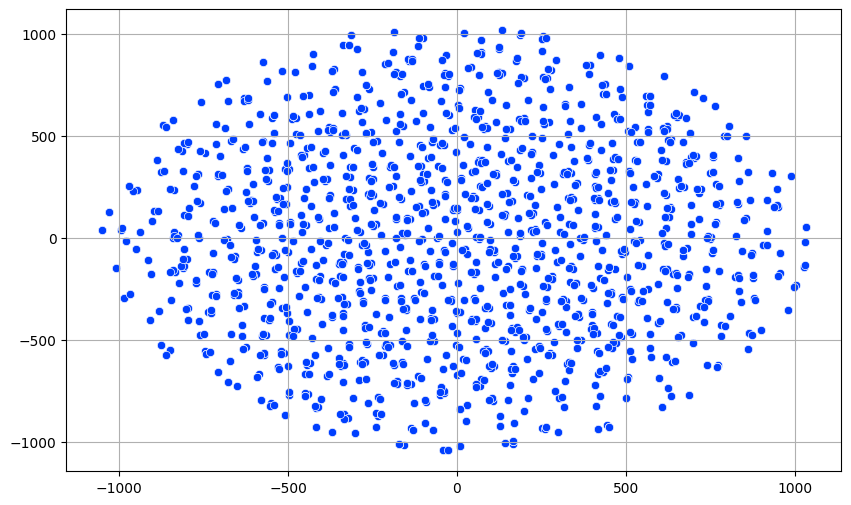

array([[ 540.3752   ,  -10.2101145],
       [-379.37576  ,   46.242786 ],
       [ 416.06876  , -669.7147   ],
       ...,
       [ 338.01117  , -616.1388   ],
       [-280.1709   ,  810.71814  ],
       [-645.9908   , -342.06586  ]], dtype=float32)

In [ ]:
plot_tsne(X, y)

### **KMeans**
(visto en clase)

#### Selección de datos

In [ ]:
# Combinaciones de columnas del dataset del 2 al n columnas
col_combinations = [comb for i in range(2, len(X.columns) + 1) for comb in list(combinations(X.columns, r=i))]

  0%|          | 0/247 [00:00<?, ?it/s]

Usando = ('Pregnancies', 'DiabetesPedigreeFunction', 'Age')


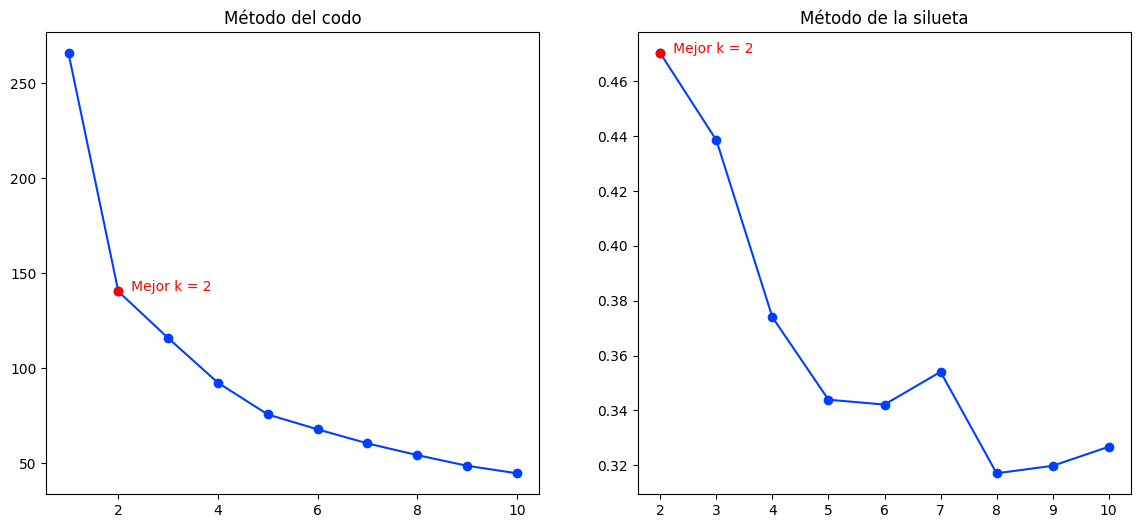

Usando = ('Pregnancies', 'BMI', 'DiabetesPedigreeFunction', 'Age')


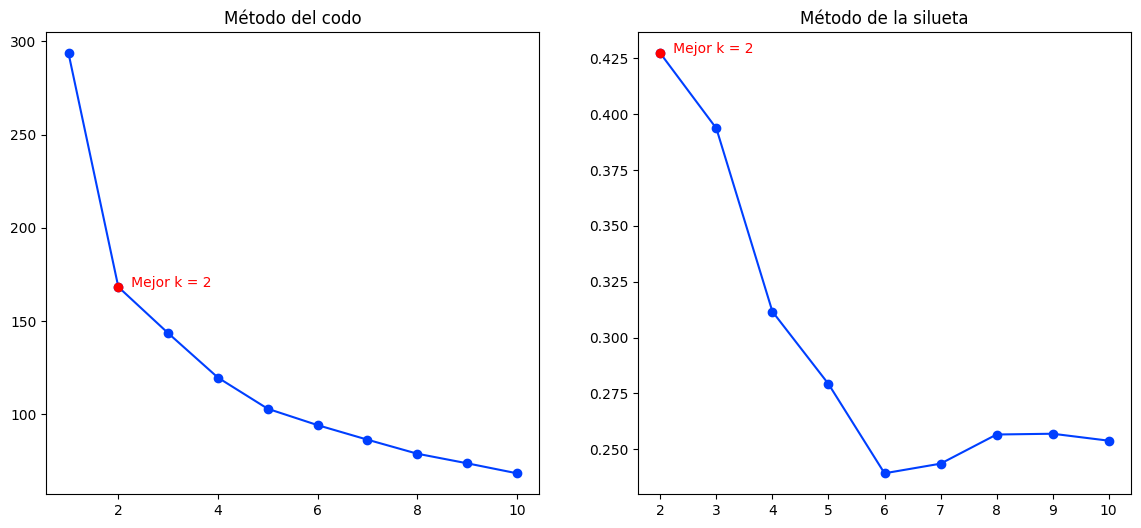

In [ ]:
plt.style.use("seaborn-v0_8-bright")

kmeans_kwargs = {
        "init": "random",
        "n_init": 10,
        "max_iter": 300,
        "random_state": 42,
        }

k2_cols = []
for cols in tqdm(col_combinations, total=len(col_combinations)):
    X_ = norm.loc[:, list(cols)]

    sse = [] # Suma de errores cuadrados
    silhouette_coefficients = []

    kmeans = KMeans(n_clusters=1, **kmeans_kwargs)
    kmeans.fit(X_)
    sse.append(kmeans.inertia_)

    for k in range(2, 11):
        kmeans = KMeans(n_clusters=k, **kmeans_kwargs)
        kmeans.fit(X_)

        sse.append(kmeans.inertia_)
        silhouette_coefficients.append(silhouette_score(X_, kmeans.labels_))

    best_k_elbow = KneeLocator(range(1, 11), sse, curve="convex", direction="decreasing").elbow # Mejor k con método del codo
    best_k_sil = max(enumerate(silhouette_coefficients, start=2), key=lambda x: x[1])[0] # Mejor K con método de la silueta

    if not (best_k_elbow == best_k_sil == 2): continue # Ignorar combinación de columnas si no cumplen con la k deseada
    k2_cols.append(cols) # Añadir combinación de columnas que cumplen con el criterio

    # Visualización
    print(f'Usando = {cols}')
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].plot(range(1, 11), sse, marker='o')
    axes[0].plot(best_k_elbow, sse[best_k_elbow - 1], marker='o', color='red')
    axes[0].text(best_k_elbow, sse[best_k_elbow - 1], '   Mejor k = ' + str(best_k_elbow), color='red')
    plt.xticks(range(1, 11))
    axes[0].set_title('Método del codo')

    axes[1].plot(range(2, 11), silhouette_coefficients, marker='o')
    axes[1].plot(best_k_sil, silhouette_coefficients[best_k_sil - 2], marker='o', color='red')
    axes[1].text(best_k_sil, silhouette_coefficients[best_k_sil - 2], '   Mejor k = ' + str(best_k_sil), color='red')
    plt.xticks(range(2, 11))
    axes[1].set_title('Método de la silueta')

    plt.show()

#### Entrenamiento

In [ ]:
X_ = norm.loc[:, k2_cols[1]]
kmeans = KMeans(n_clusters=2, **kmeans_kwargs)
kmeans.fit(X_)

evaluate(y, kmeans.labels_, str(k2_cols[1]) + '\t---')

('Pregnancies', 'BMI', 'DiabetesPedigreeFunction', 'Age')	---	 Accuracy = 66.94%    	 F1 Score = 49.97%


#### Visualización

              precision    recall  f1-score   support

           0       0.74      0.77      0.75      1816
           1       0.52      0.48      0.50       952

    accuracy                           0.67      2768
   macro avg       0.63      0.62      0.63      2768
weighted avg       0.66      0.67      0.67      2768



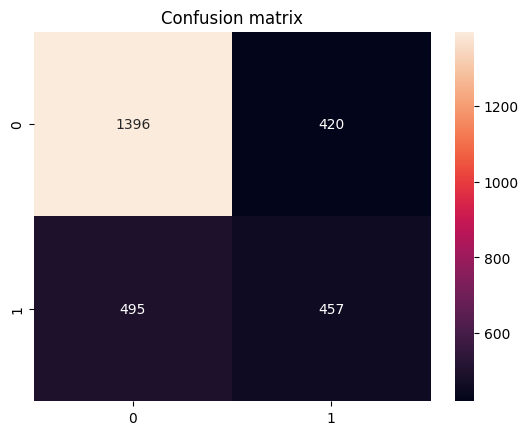

In [ ]:
visualize_metrics(y, kmeans.labels_) # Matriz de confusión para comparar

### **Modelo de Mezcla Gaussiana**
(no visto en clase)

#### Selección de datos

  0%|          | 0/247 [00:00<?, ?it/s]

Usando = ('Pregnancies', 'Age')


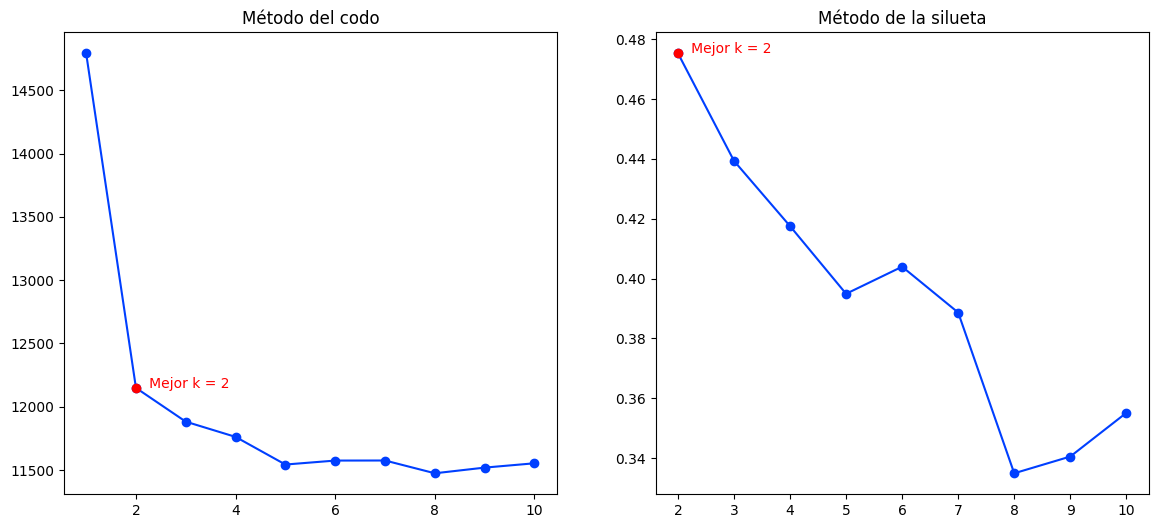

Usando = ('SkinThickness', 'BMI')


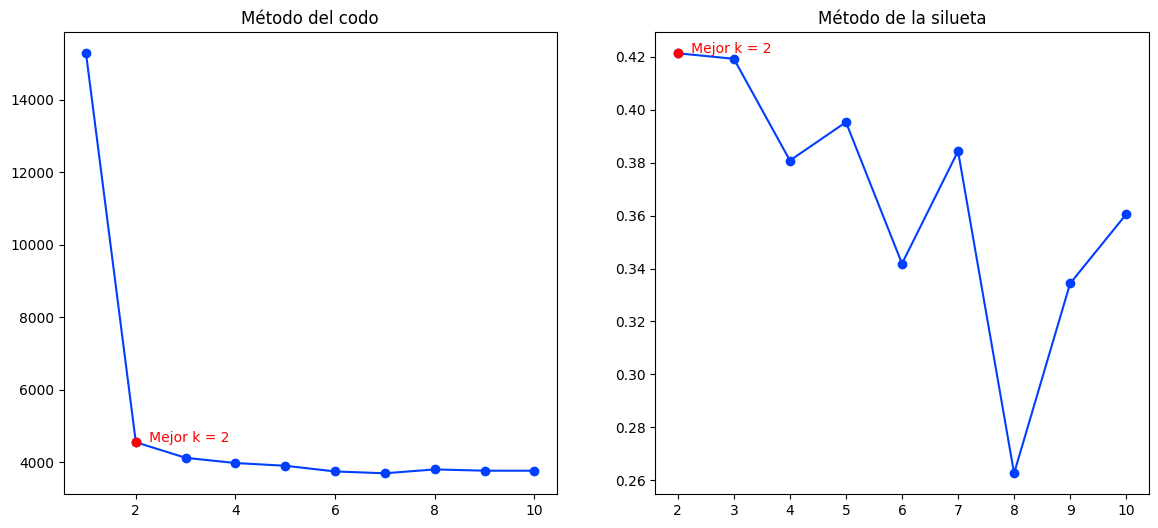

Usando = ('SkinThickness', 'Age')


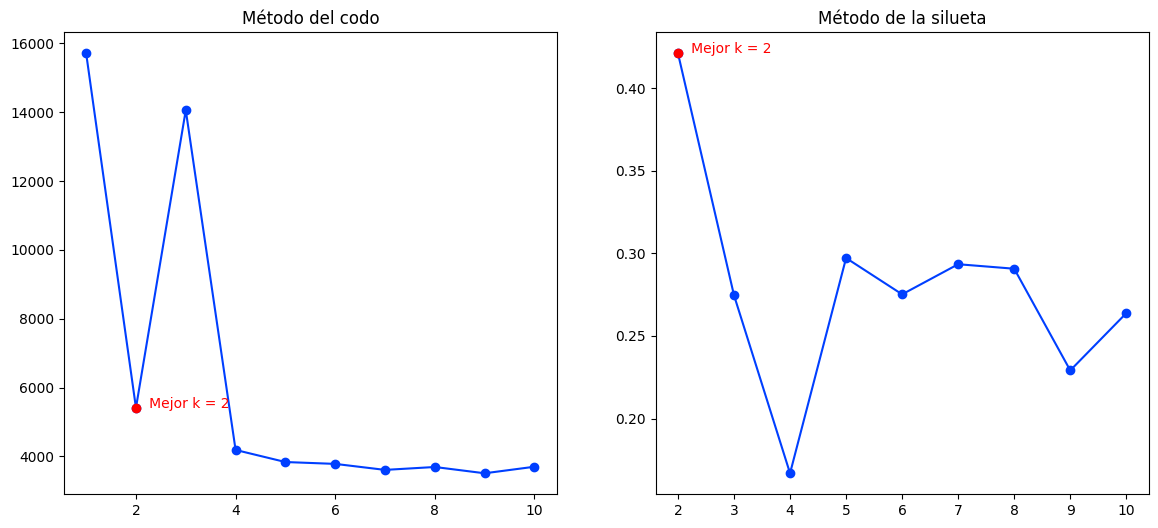

Usando = ('Insulin', 'BMI')


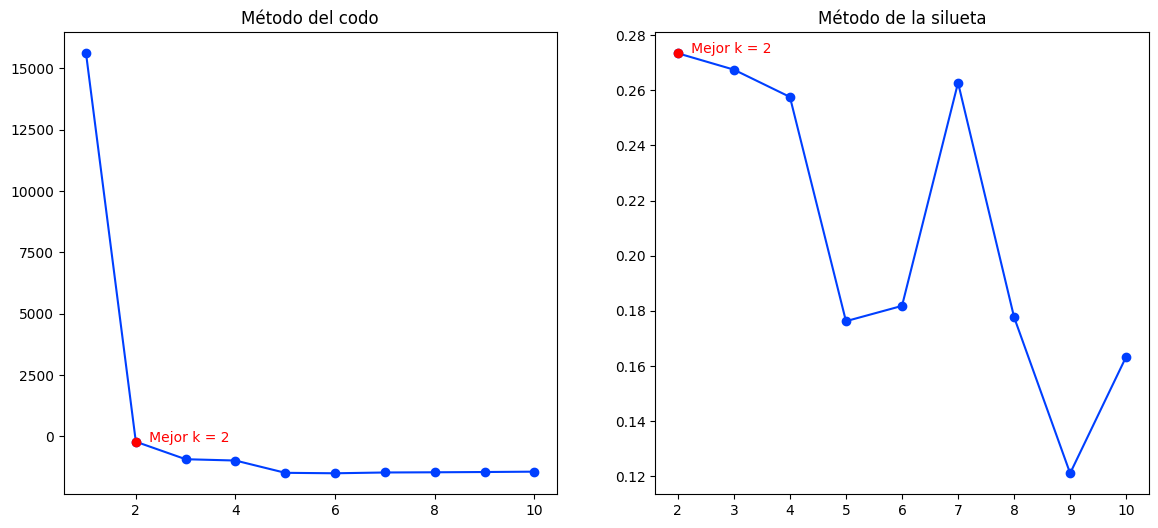

Usando = ('BMI', 'Age')


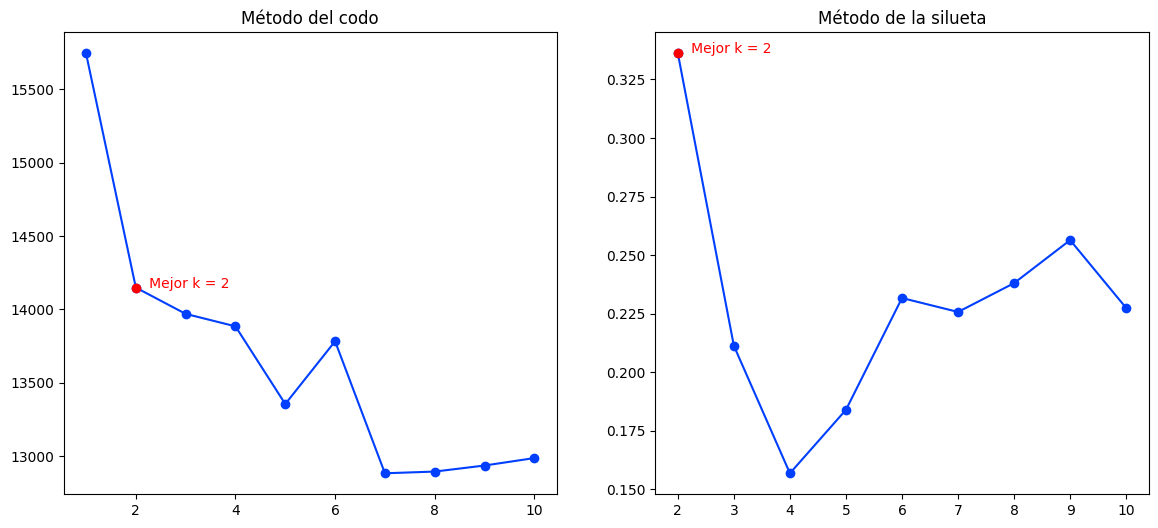

Usando = ('Pregnancies', 'Glucose', 'SkinThickness')


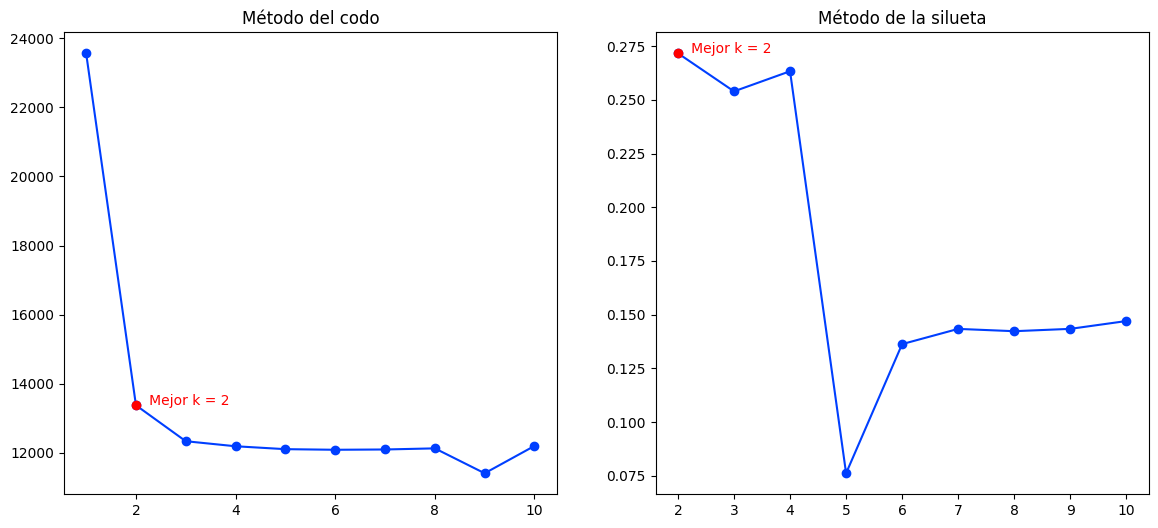

Usando = ('Pregnancies', 'Glucose', 'Insulin')


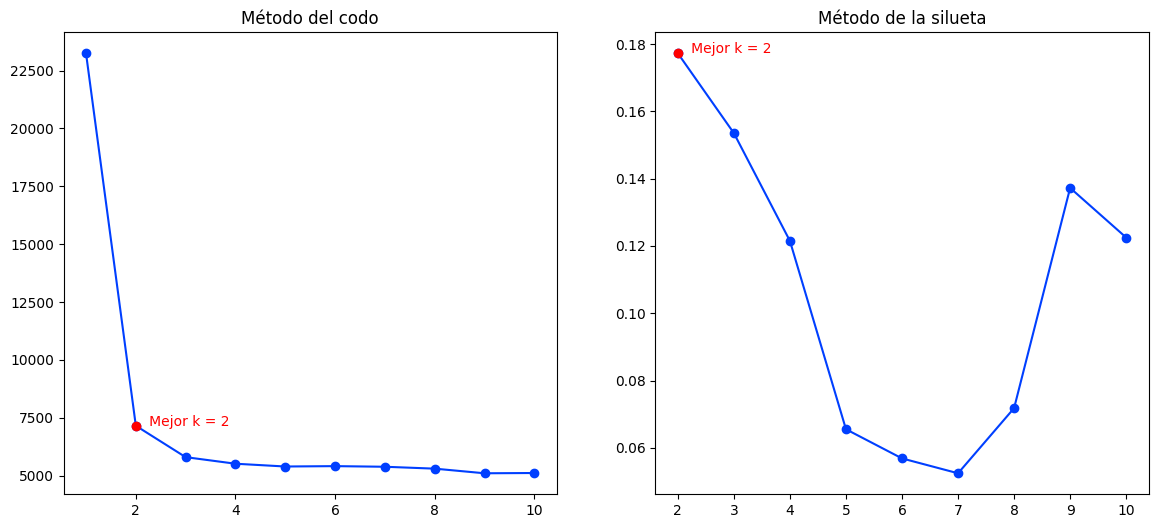

Usando = ('Pregnancies', 'Glucose', 'Age')


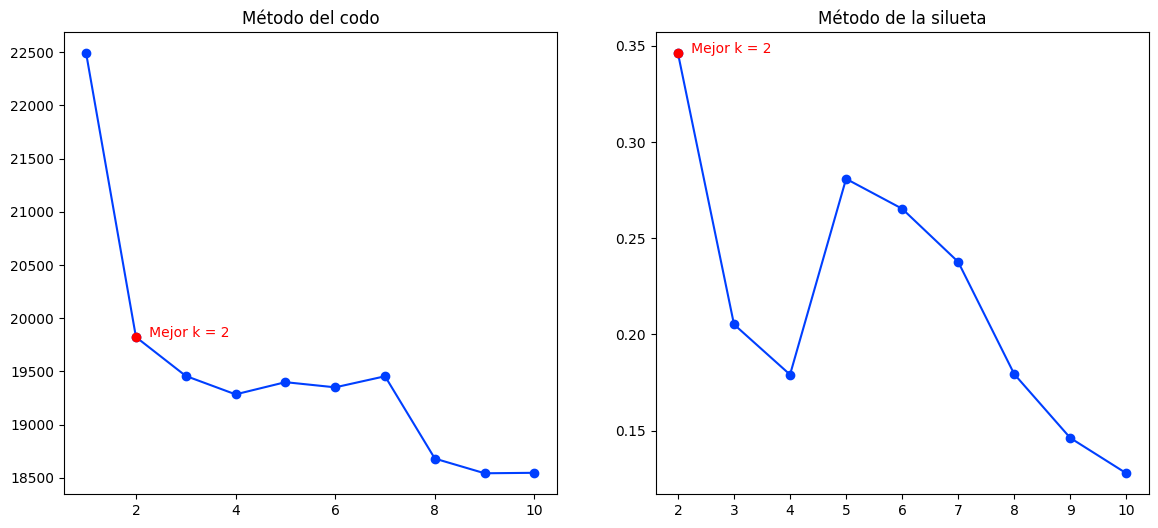

Usando = ('Pregnancies', 'Insulin', 'BMI')


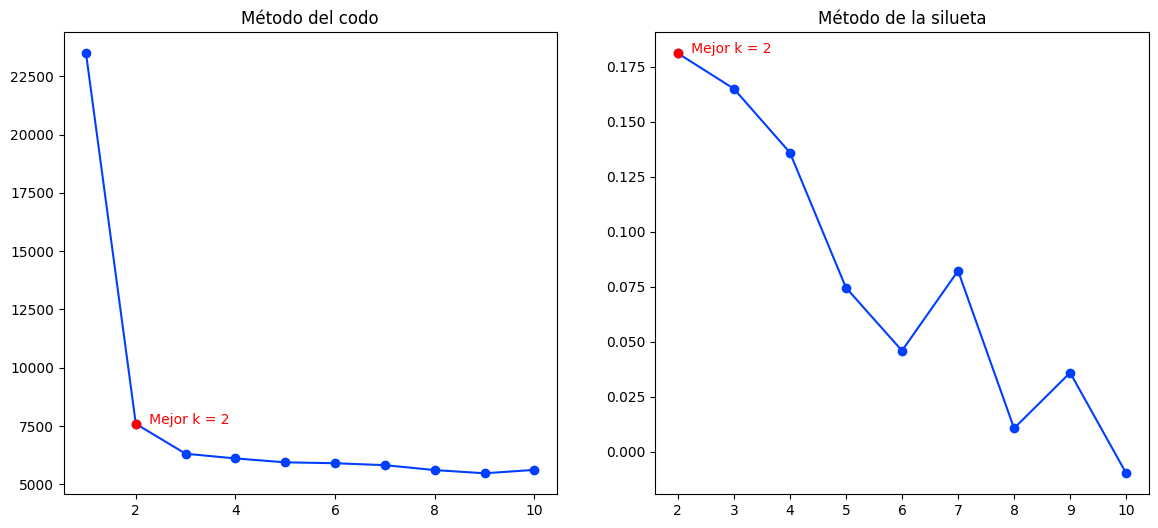

Usando = ('Pregnancies', 'BMI', 'Age')


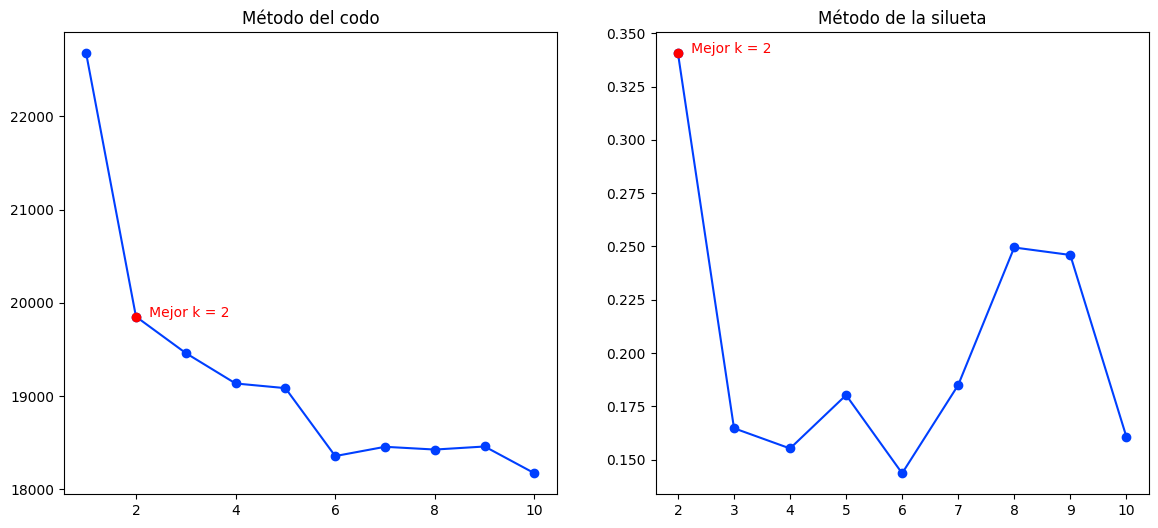

Usando = ('Glucose', 'SkinThickness', 'BMI')


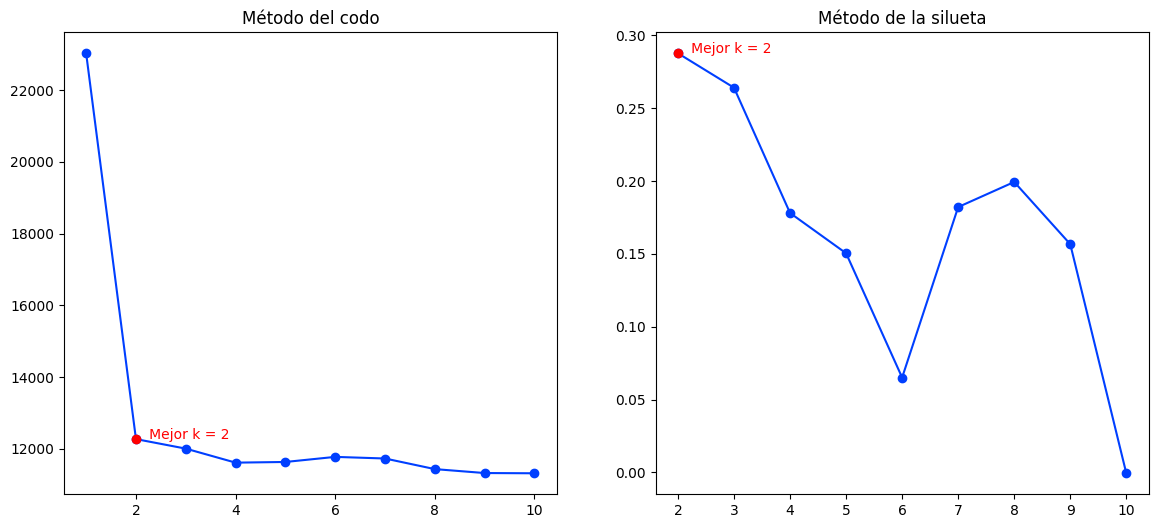

Usando = ('Glucose', 'Insulin', 'BMI')


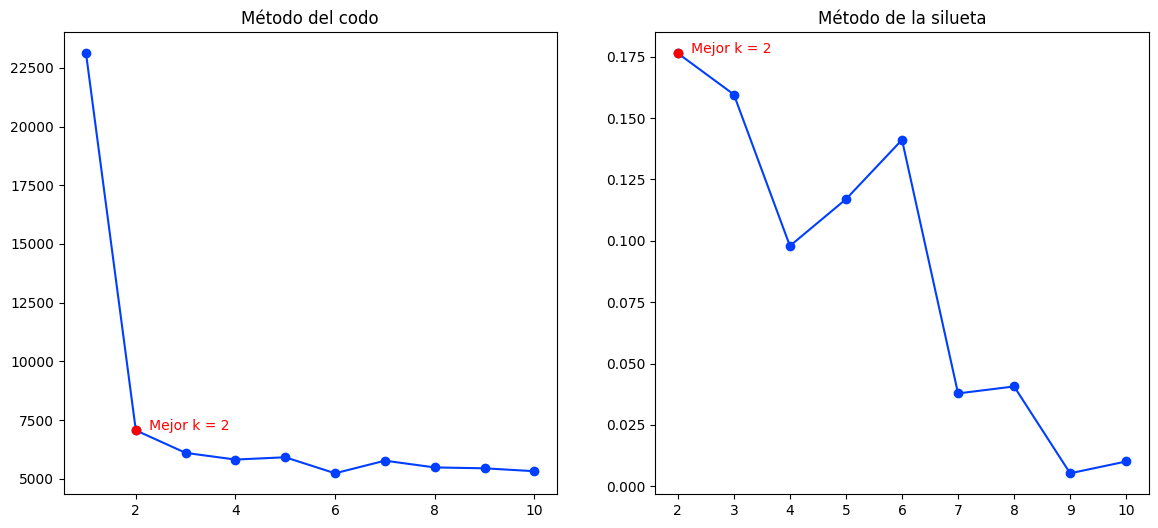

Usando = ('Glucose', 'Insulin', 'DiabetesPedigreeFunction')


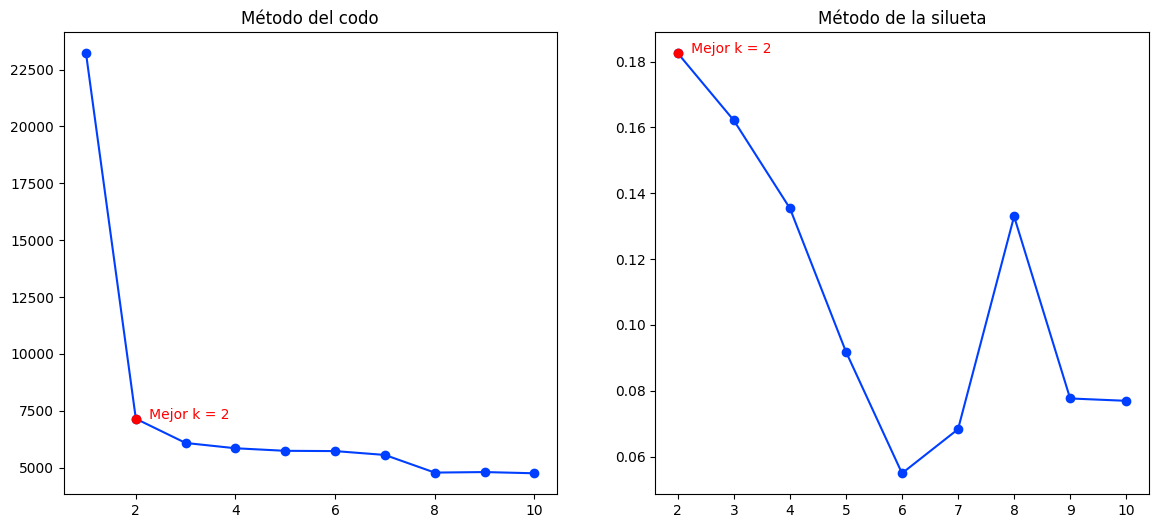

Usando = ('Glucose', 'BMI', 'Age')


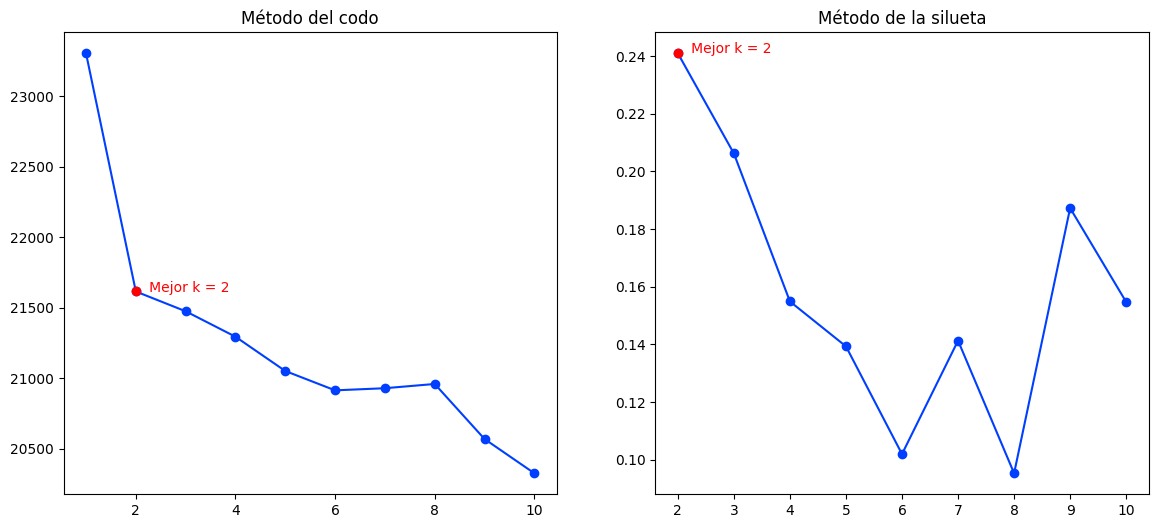

Usando = ('BloodPressure', 'SkinThickness', 'DiabetesPedigreeFunction')


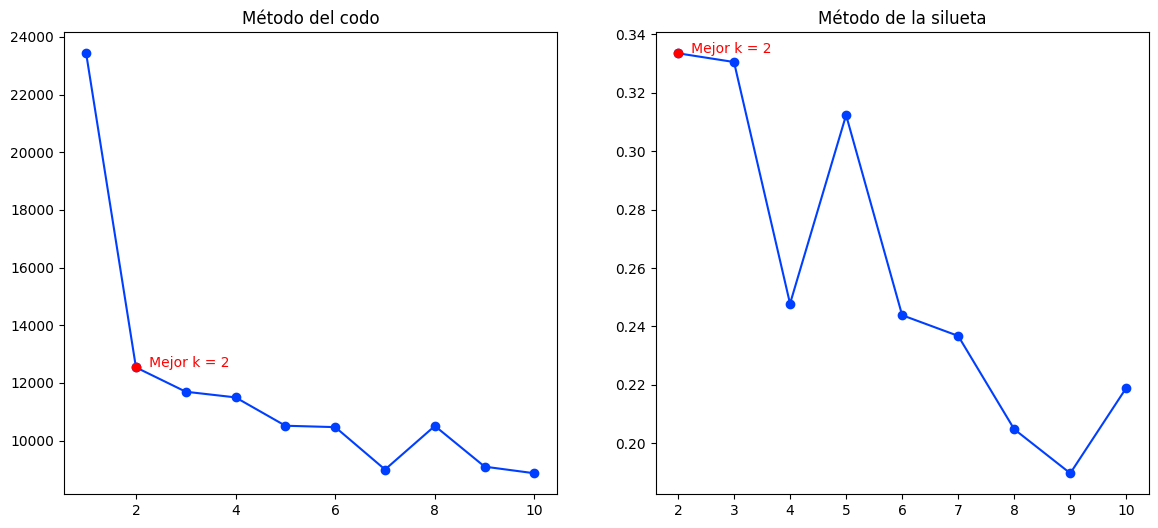

Usando = ('SkinThickness', 'Insulin', 'Age')


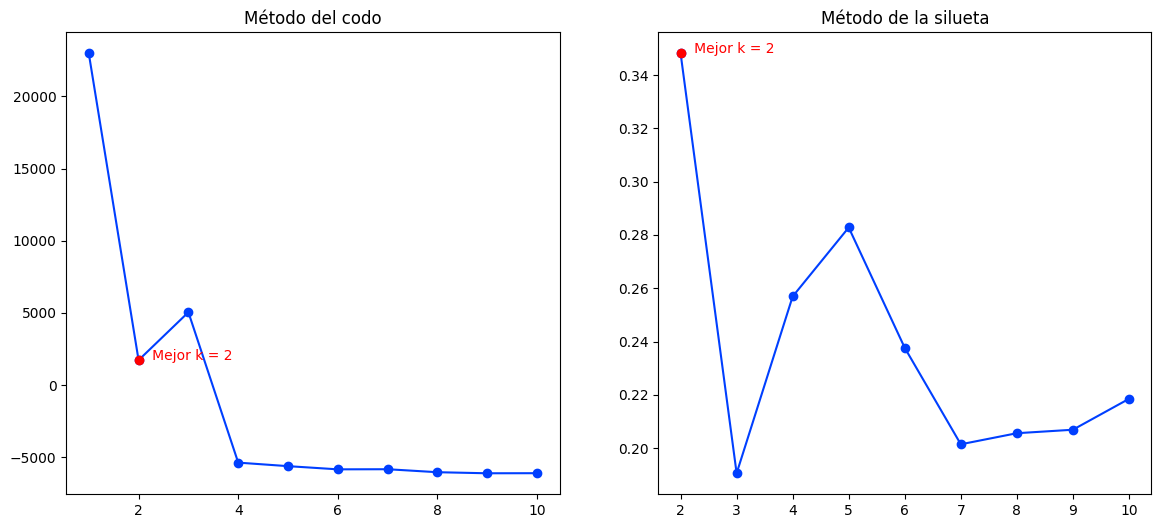

Usando = ('SkinThickness', 'BMI', 'Age')


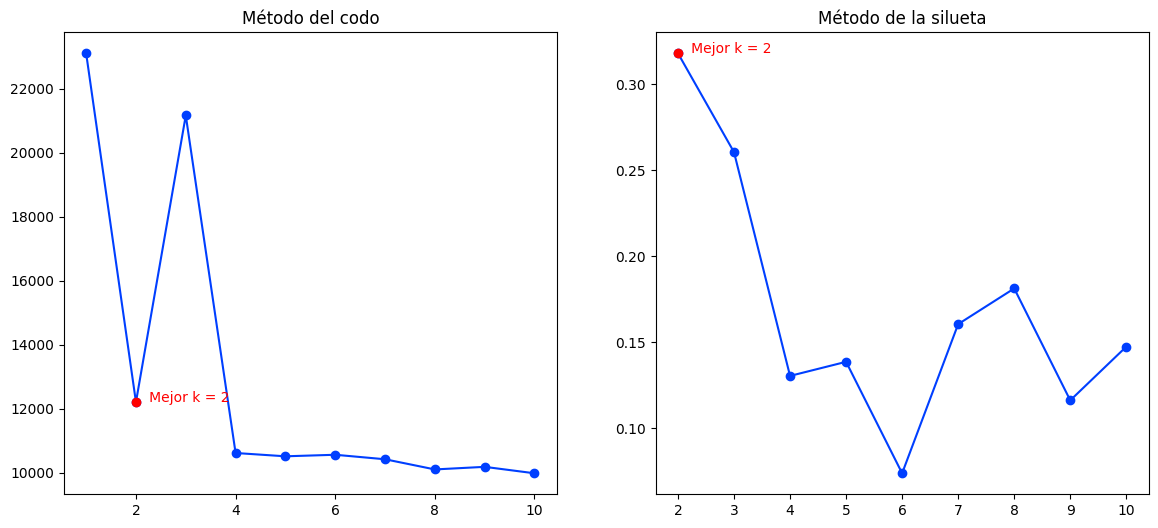

Usando = ('Insulin', 'BMI', 'DiabetesPedigreeFunction')


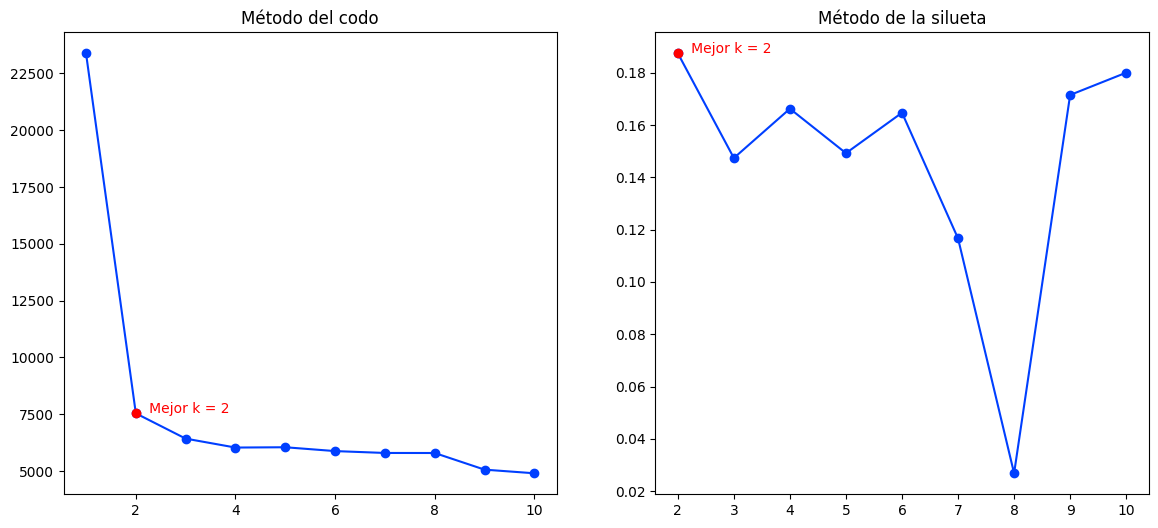

Usando = ('Insulin', 'DiabetesPedigreeFunction', 'Age')


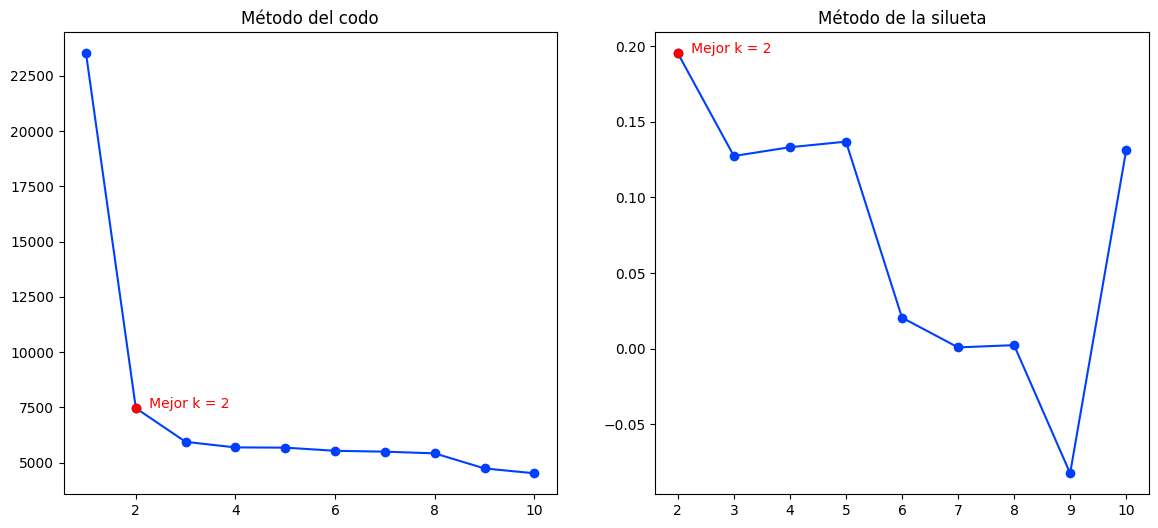

Usando = ('Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness')


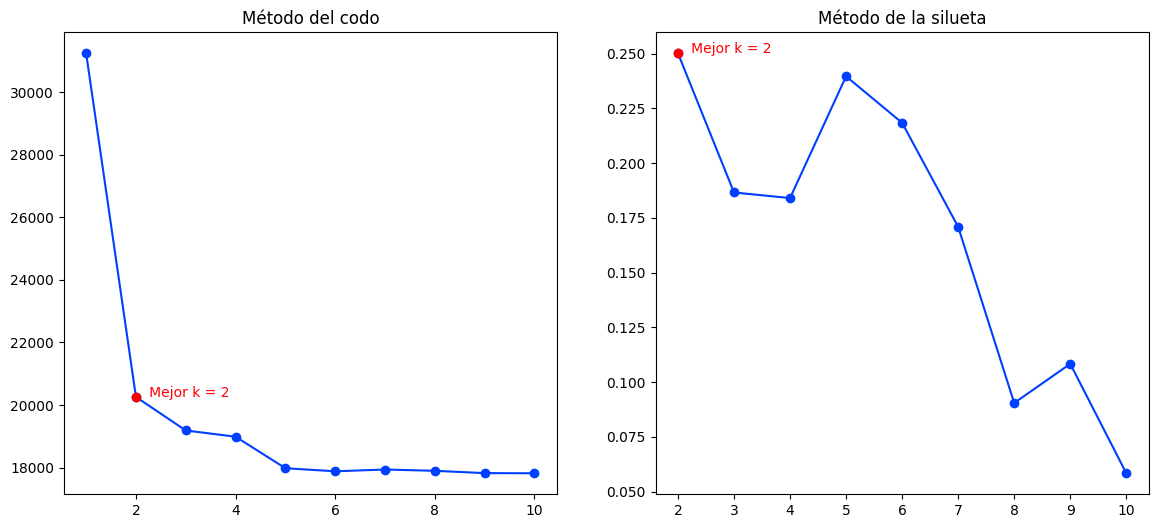

Usando = ('Pregnancies', 'Glucose', 'SkinThickness', 'BMI')


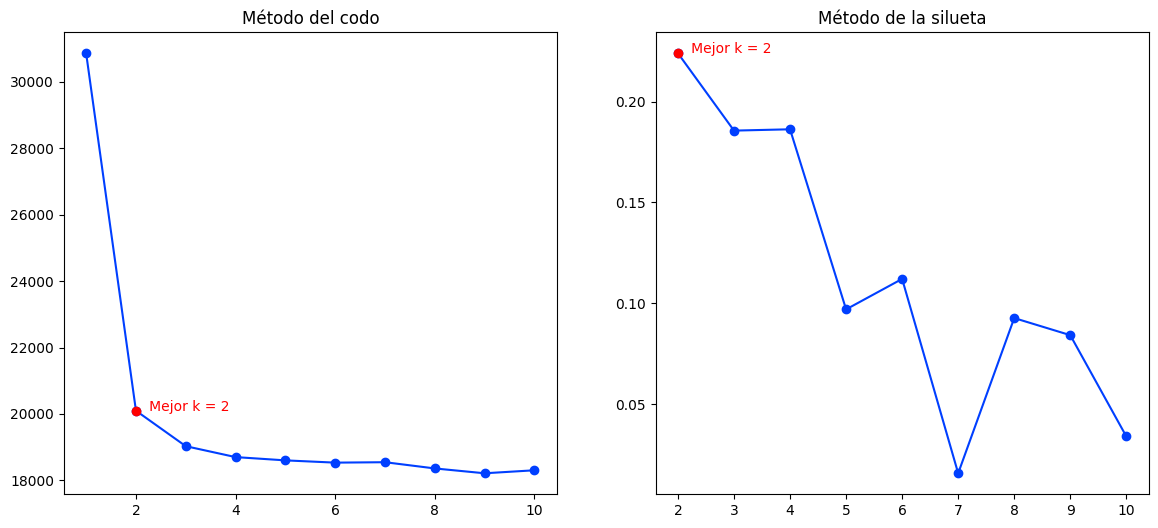

Usando = ('Pregnancies', 'Glucose', 'Insulin', 'BMI')


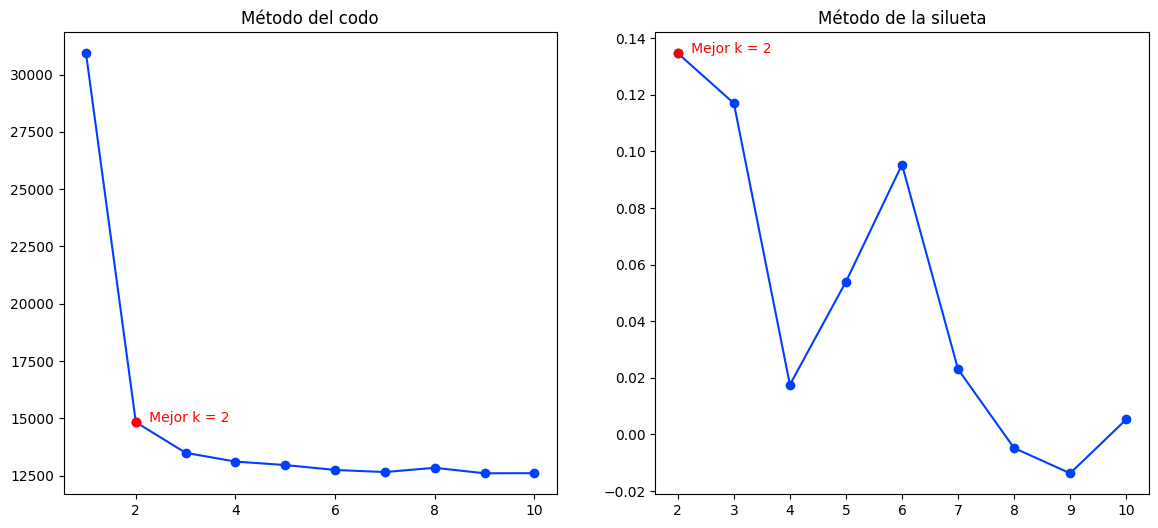

Usando = ('Pregnancies', 'Glucose', 'Insulin', 'DiabetesPedigreeFunction')


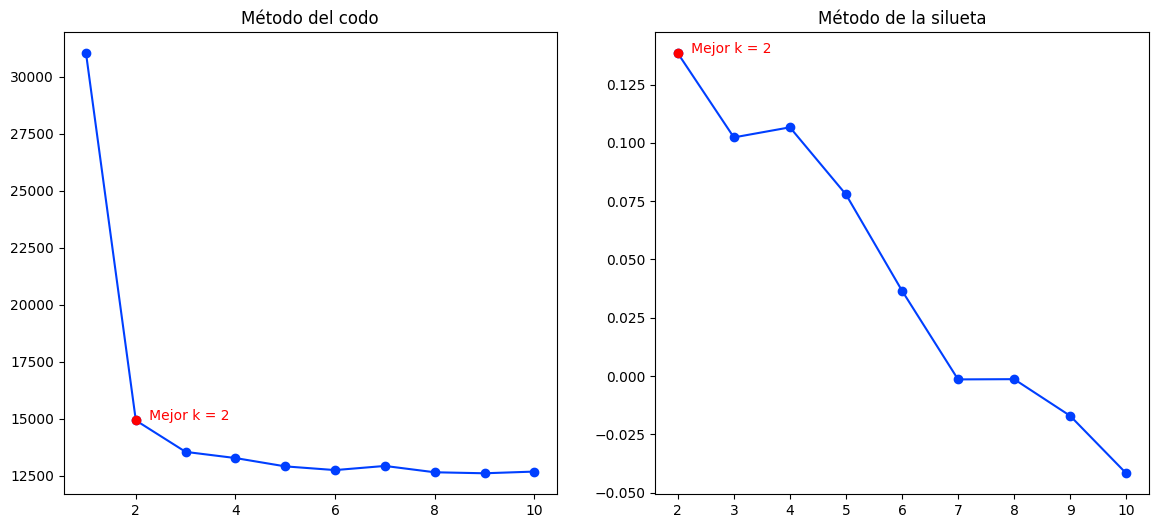

Usando = ('Pregnancies', 'Glucose', 'BMI', 'Age')


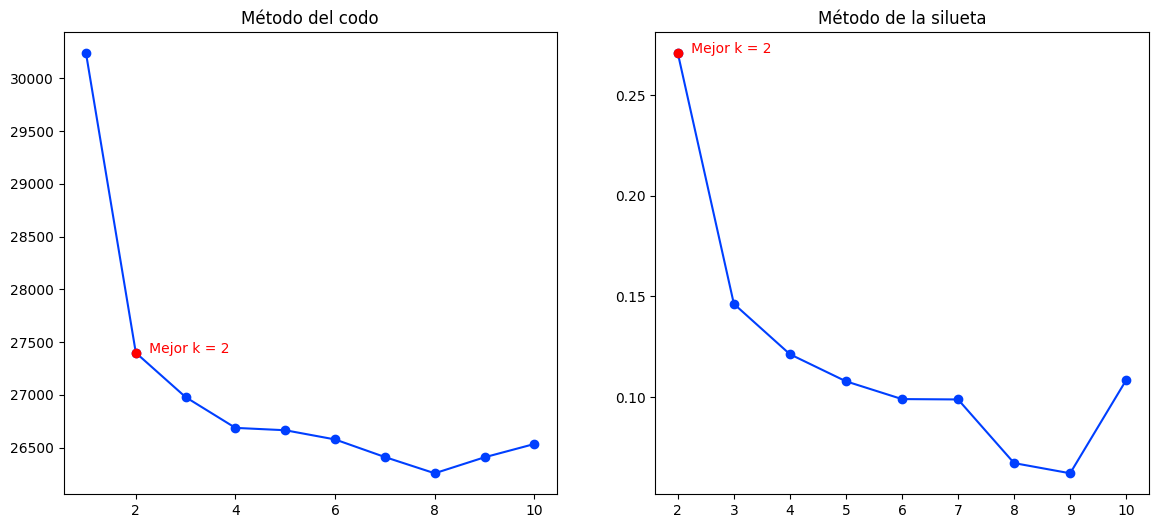

Usando = ('Pregnancies', 'BloodPressure', 'SkinThickness', 'BMI')


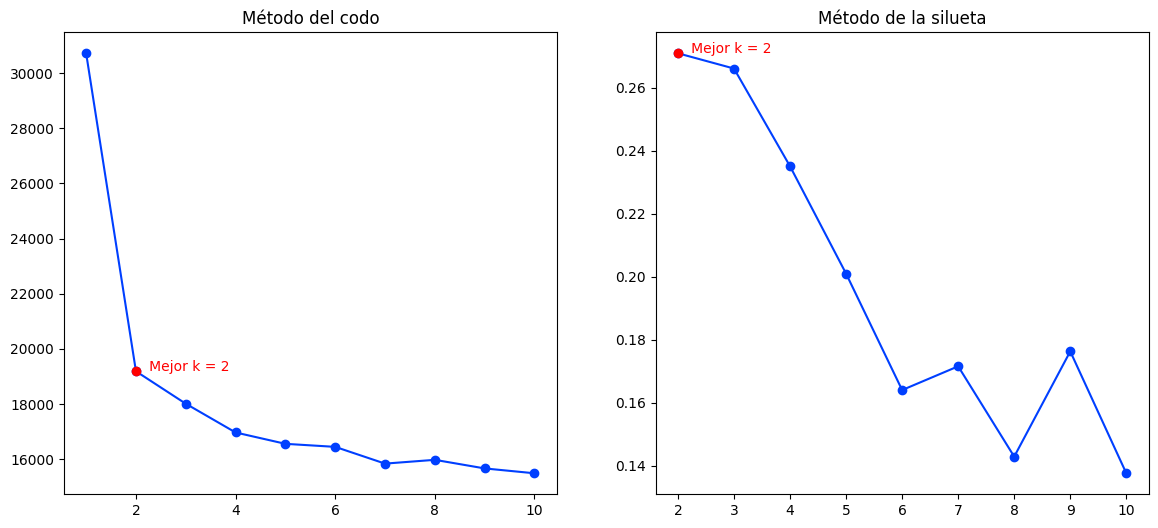

Usando = ('Pregnancies', 'BloodPressure', 'Insulin', 'Age')


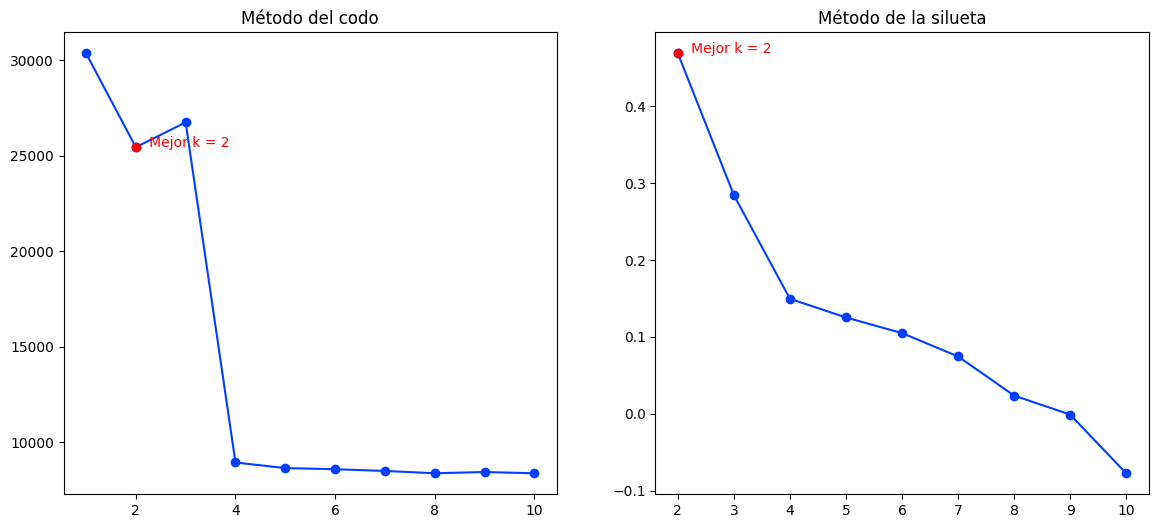

Usando = ('Pregnancies', 'BloodPressure', 'BMI', 'DiabetesPedigreeFunction')


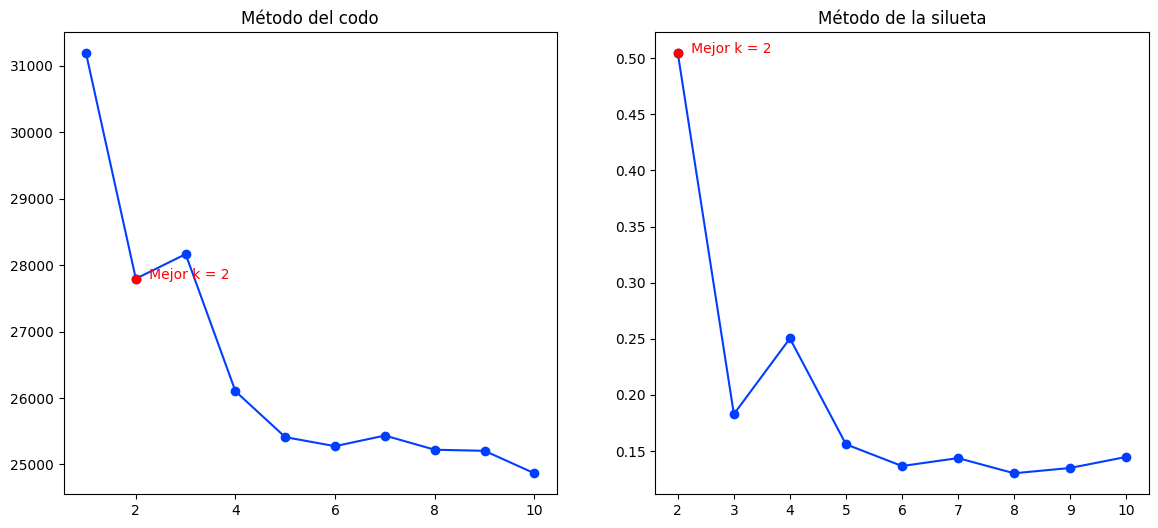

Usando = ('Pregnancies', 'SkinThickness', 'Insulin', 'BMI')


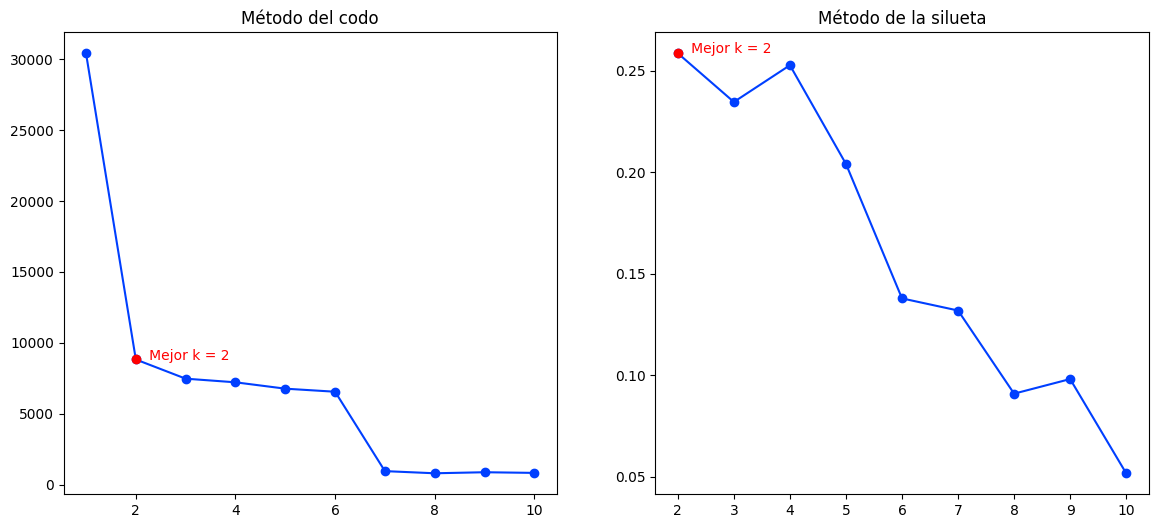

Usando = ('Pregnancies', 'SkinThickness', 'BMI', 'DiabetesPedigreeFunction')


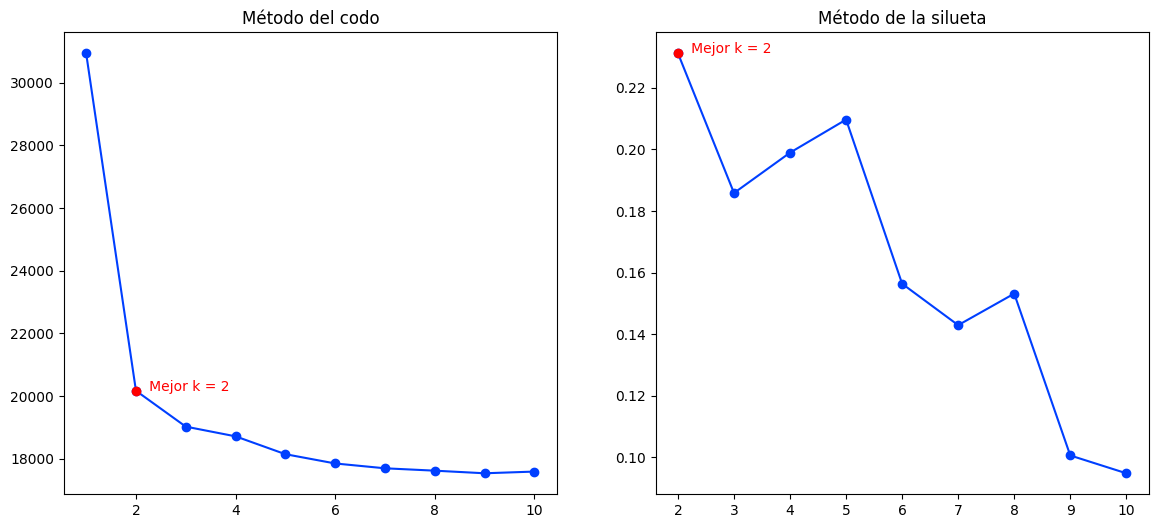

Usando = ('Glucose', 'BloodPressure', 'SkinThickness', 'BMI')


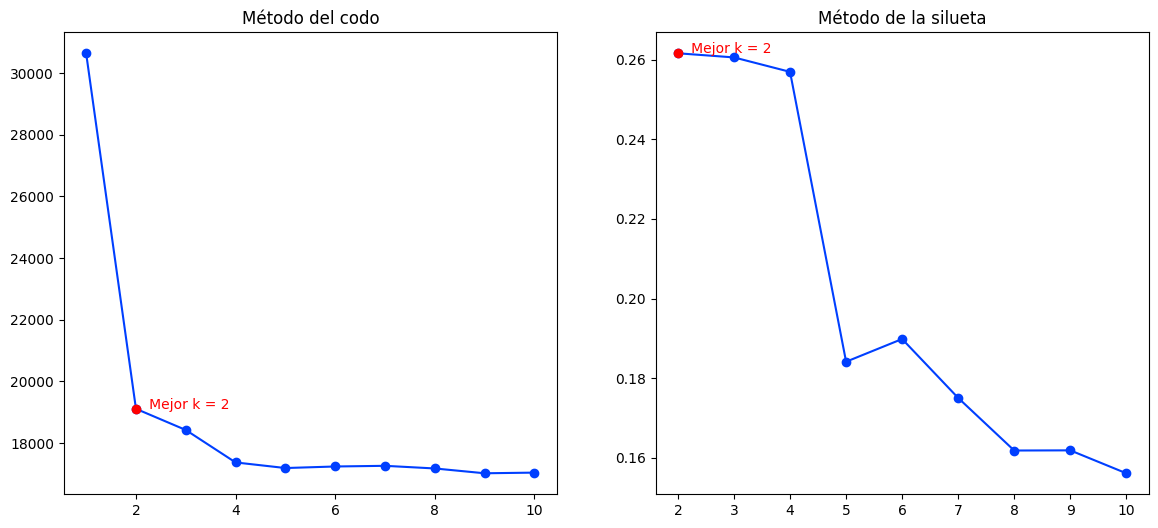

Usando = ('Glucose', 'BloodPressure', 'SkinThickness', 'Age')


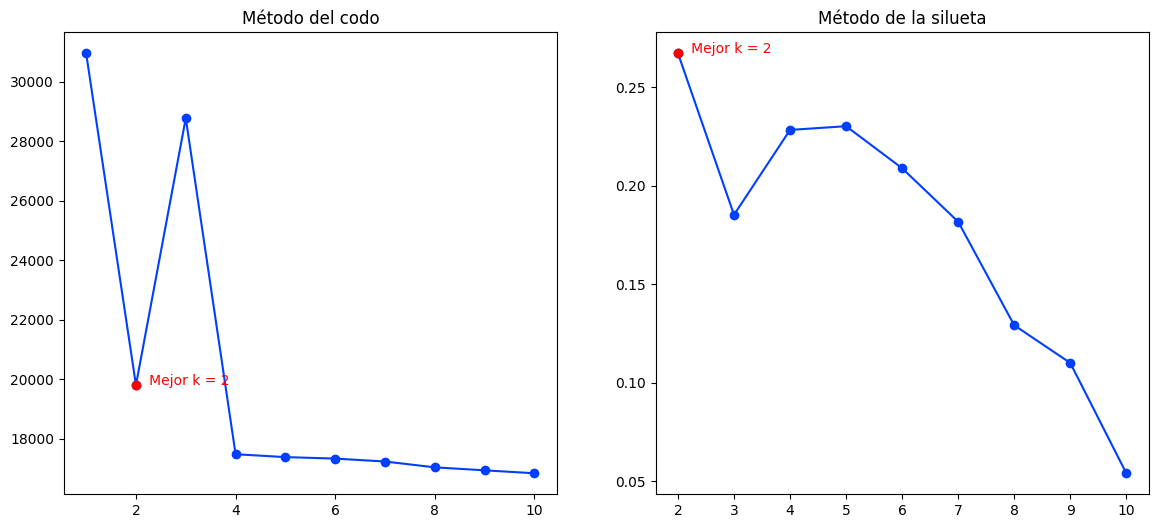

Usando = ('Glucose', 'SkinThickness', 'BMI', 'Age')


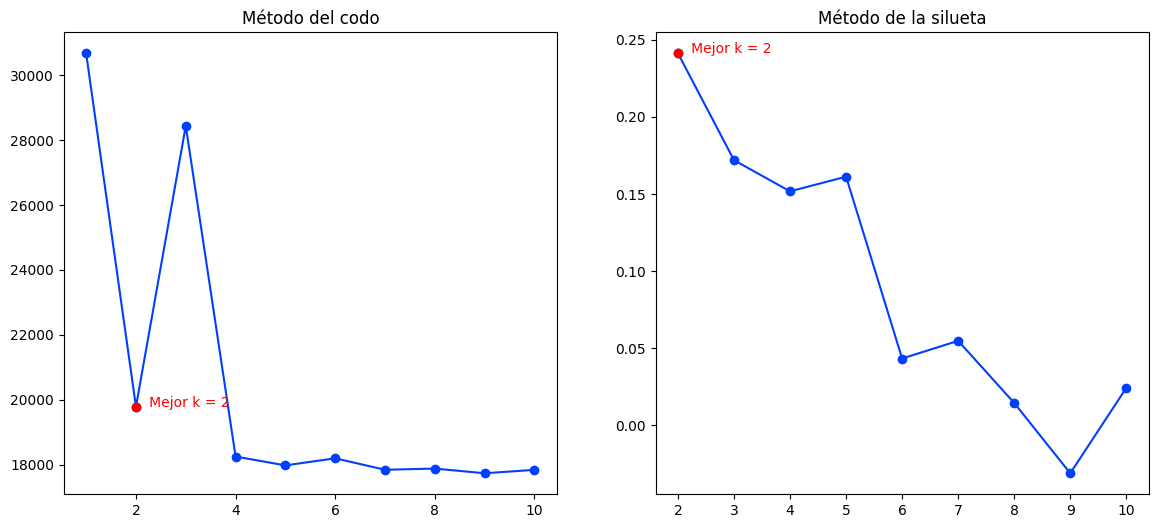

Usando = ('Glucose', 'Insulin', 'BMI', 'DiabetesPedigreeFunction')


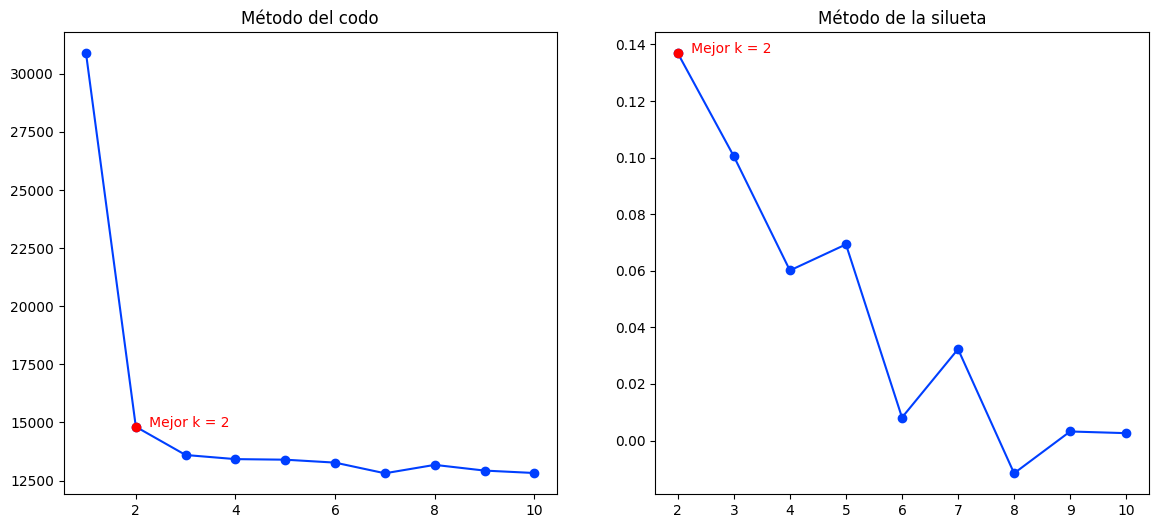

Usando = ('BloodPressure', 'SkinThickness', 'BMI', 'Age')


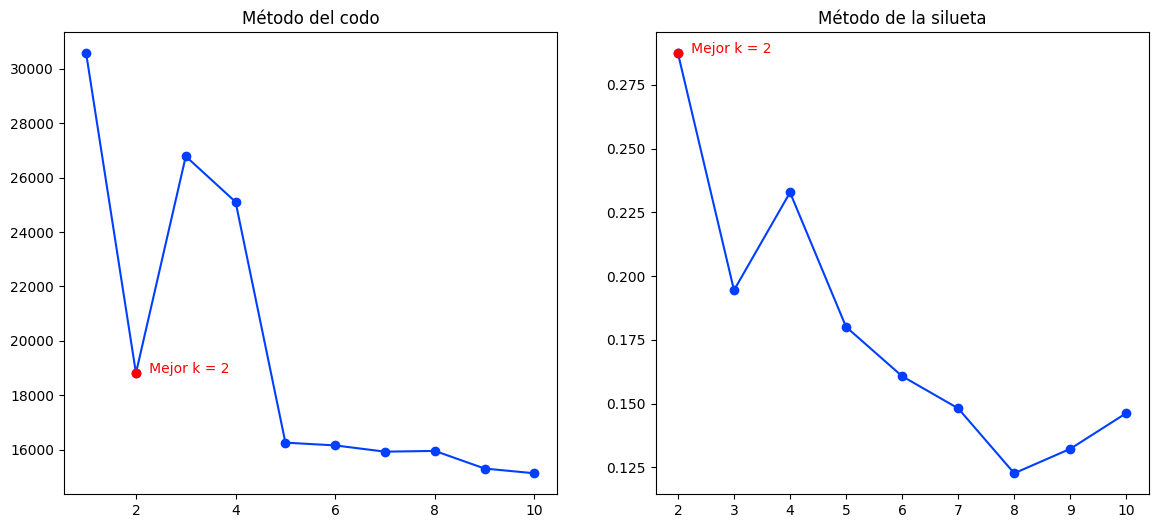

Usando = ('BloodPressure', 'SkinThickness', 'DiabetesPedigreeFunction', 'Age')


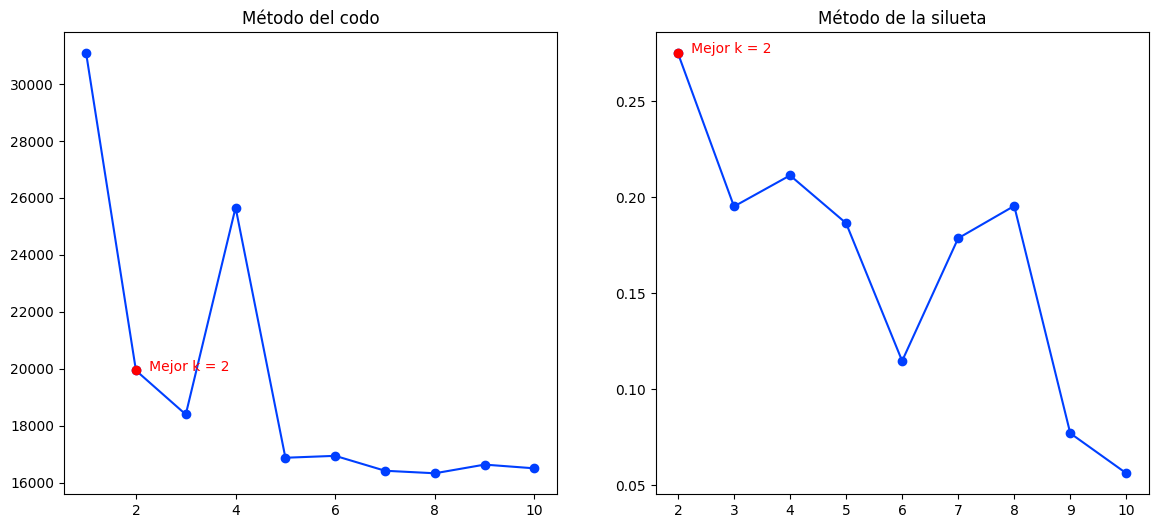

Usando = ('SkinThickness', 'Insulin', 'BMI', 'Age')


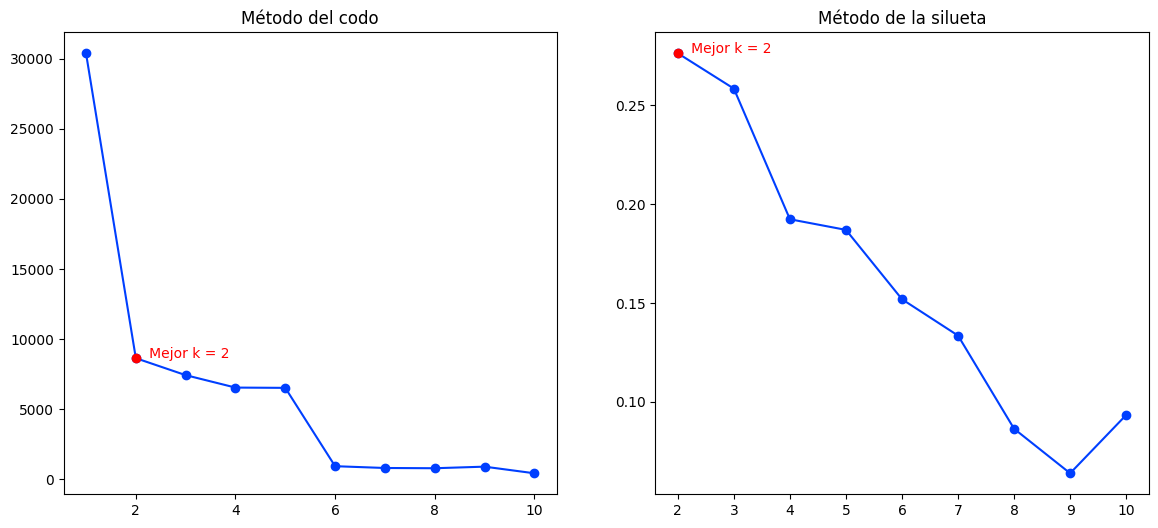

Usando = ('SkinThickness', 'Insulin', 'DiabetesPedigreeFunction', 'Age')


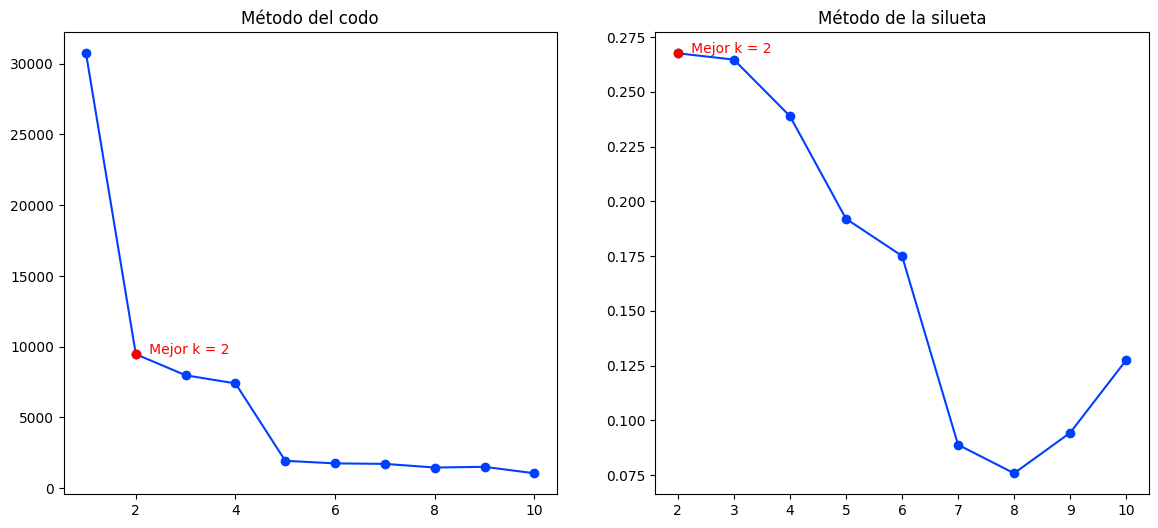

Usando = ('Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'BMI')


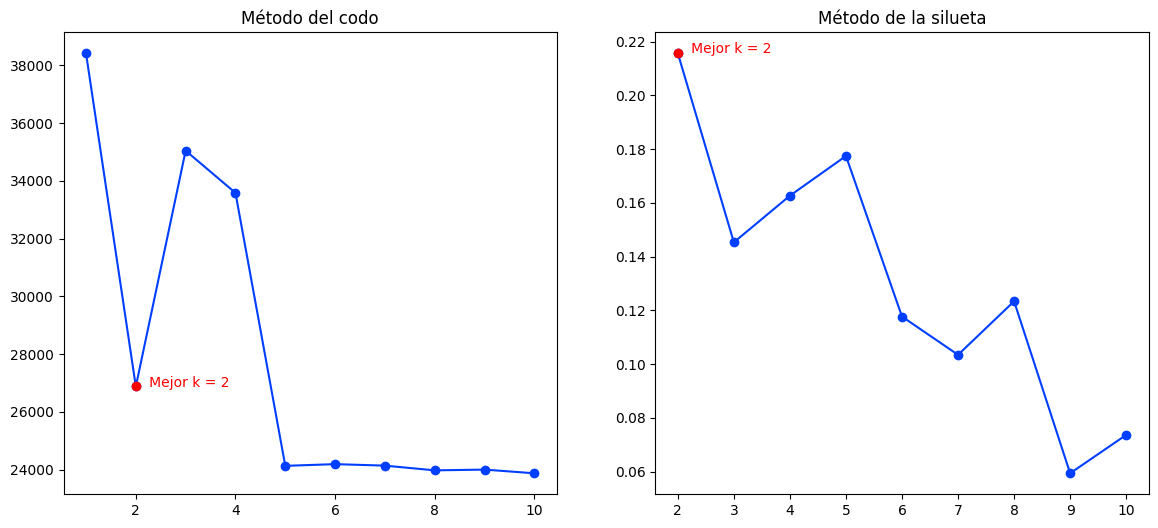

Usando = ('Pregnancies', 'Glucose', 'SkinThickness', 'Insulin', 'BMI')


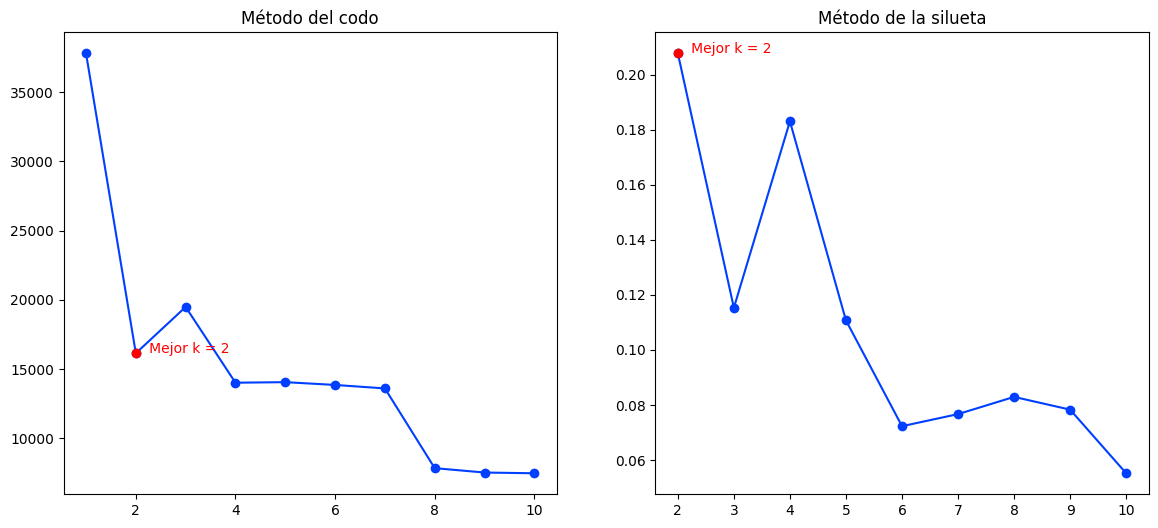

Usando = ('Pregnancies', 'Glucose', 'Insulin', 'BMI', 'DiabetesPedigreeFunction')


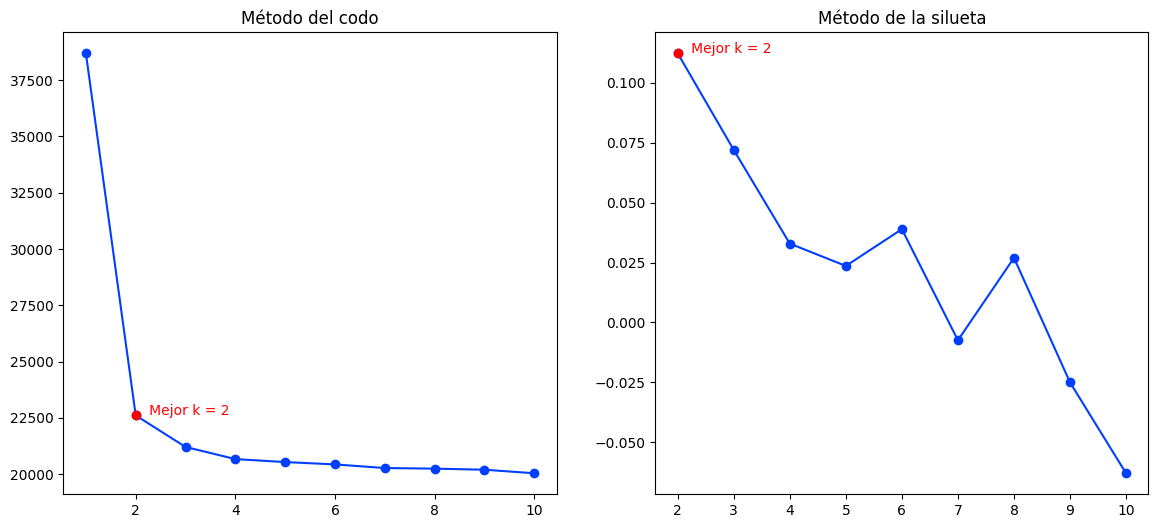

Usando = ('Pregnancies', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI')


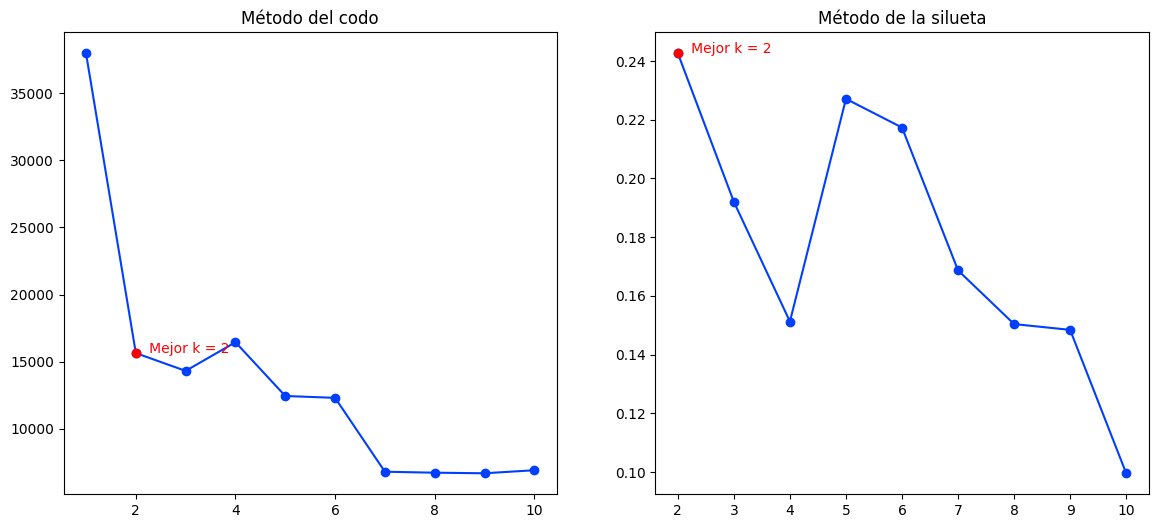

Usando = ('Pregnancies', 'BloodPressure', 'SkinThickness', 'Insulin', 'DiabetesPedigreeFunction')


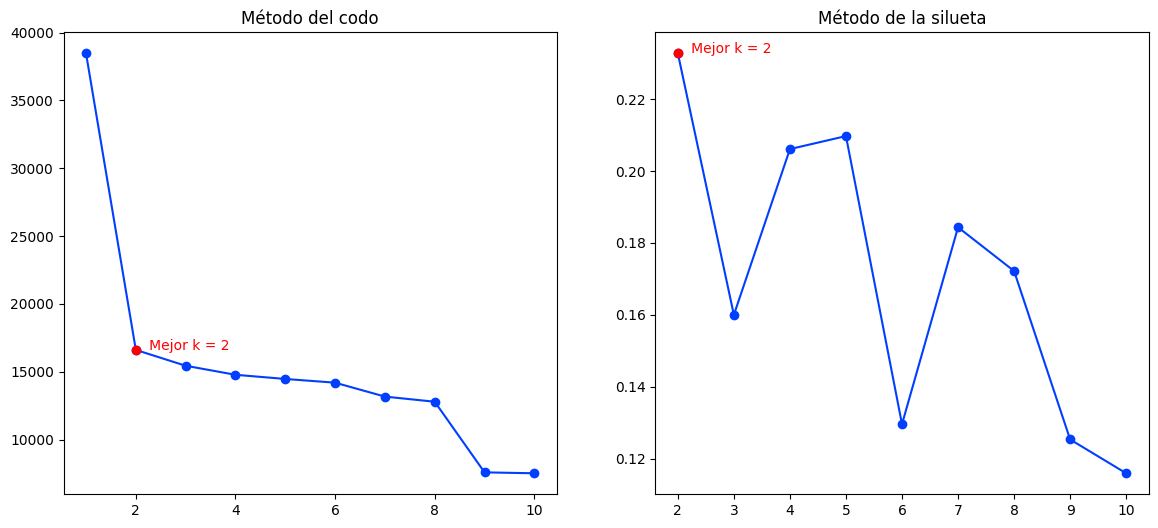

Usando = ('Pregnancies', 'BloodPressure', 'SkinThickness', 'BMI', 'DiabetesPedigreeFunction')


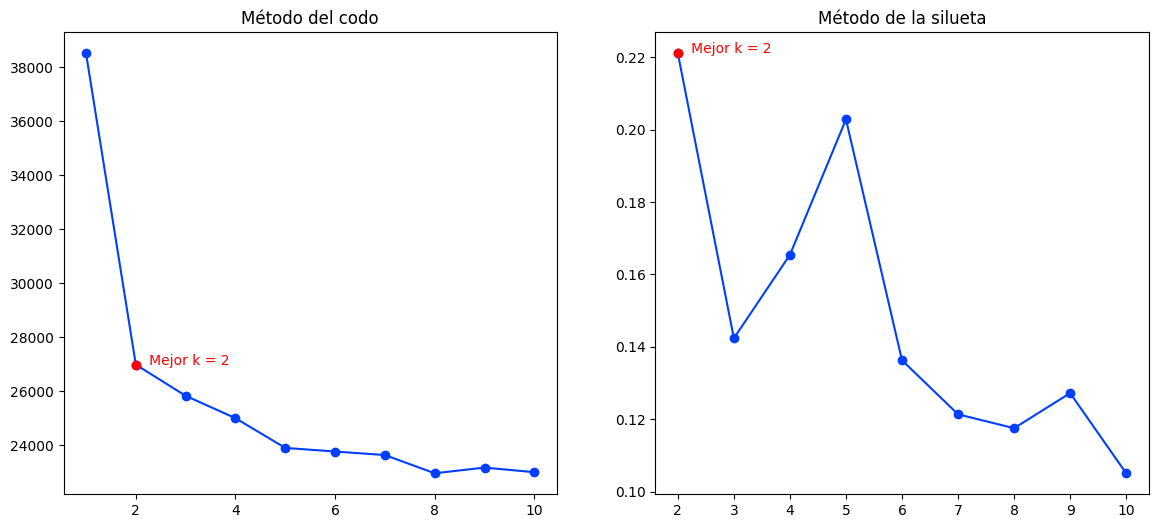

Usando = ('Pregnancies', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction')


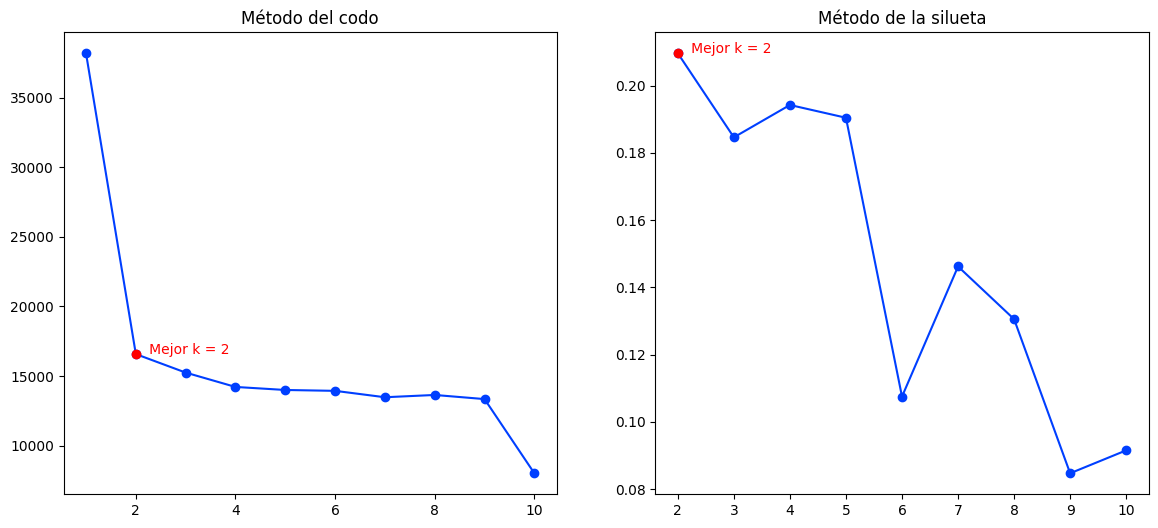

Usando = ('Glucose', 'BloodPressure', 'SkinThickness', 'BMI', 'DiabetesPedigreeFunction')


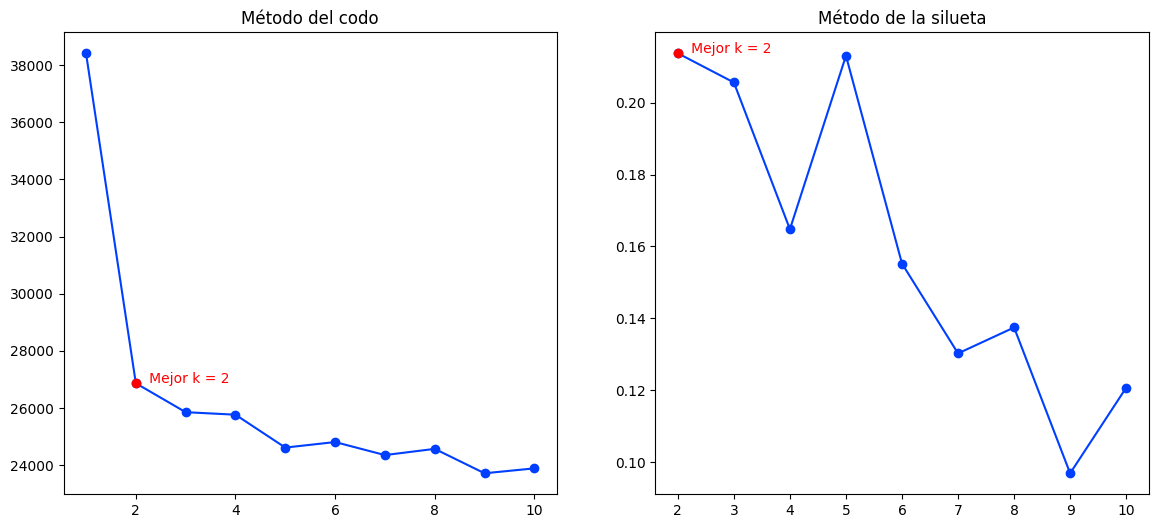

Usando = ('Glucose', 'BloodPressure', 'SkinThickness', 'BMI', 'Age')


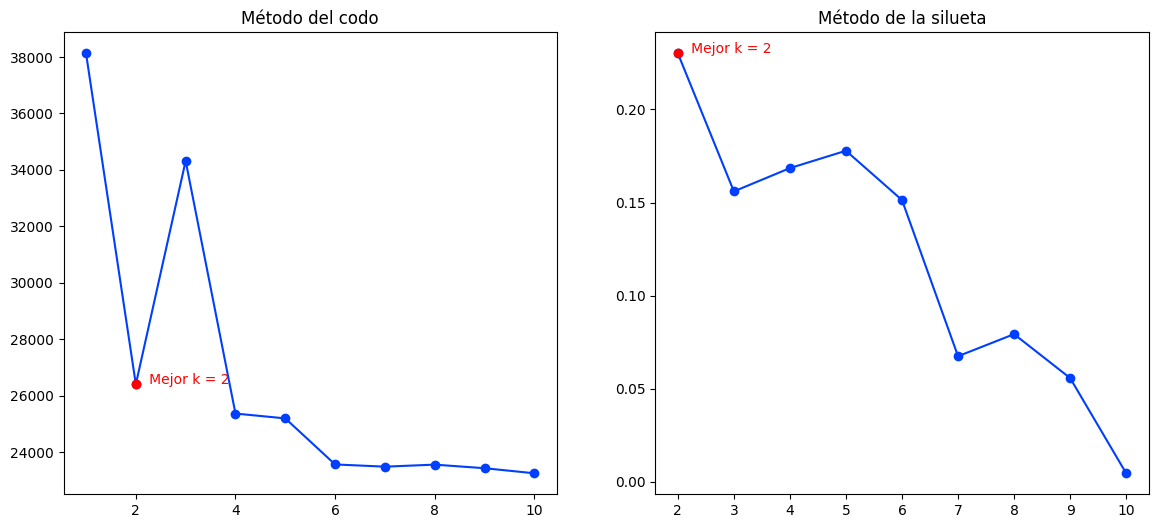

Usando = ('Glucose', 'BloodPressure', 'Insulin', 'BMI', 'DiabetesPedigreeFunction')


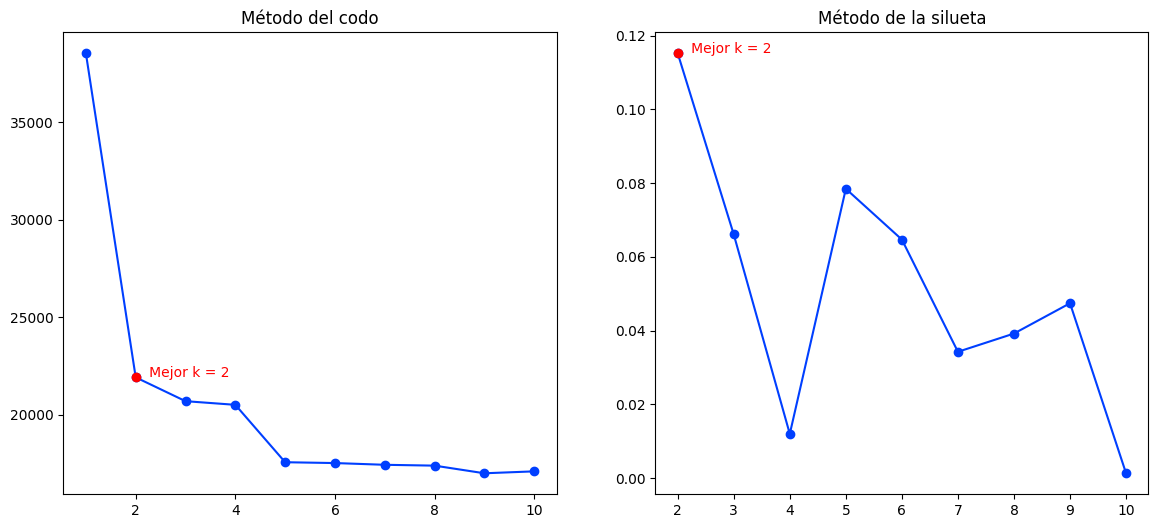

Usando = ('Glucose', 'BloodPressure', 'Insulin', 'DiabetesPedigreeFunction', 'Age')


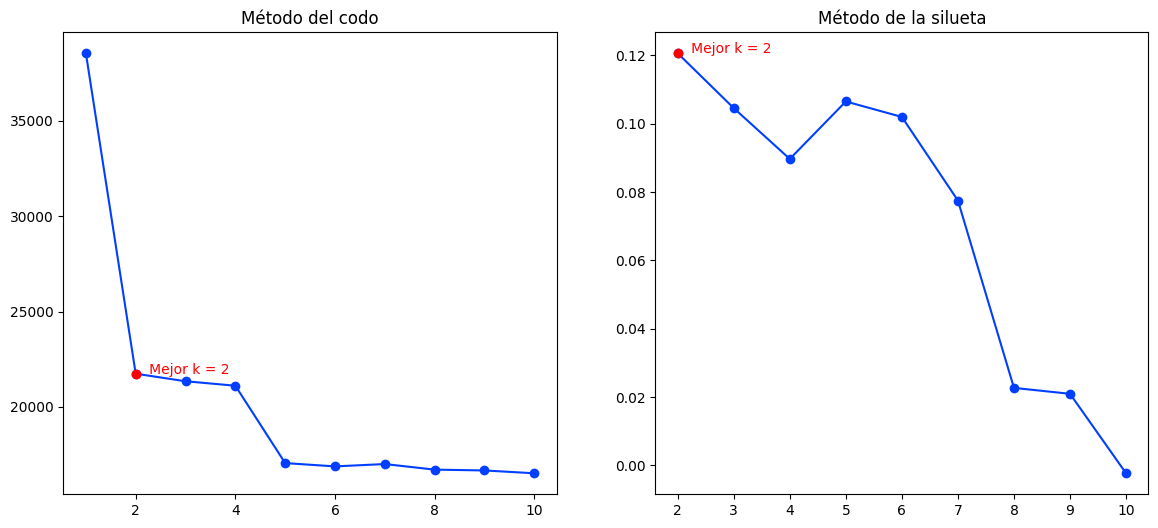

Usando = ('Glucose', 'SkinThickness', 'Insulin', 'BMI', 'Age')


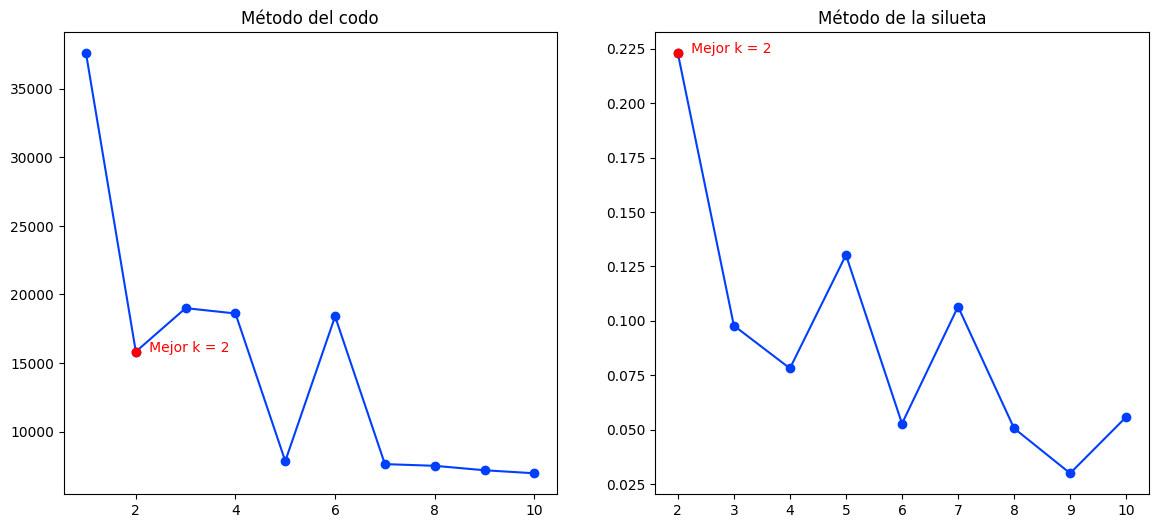

Usando = ('Glucose', 'SkinThickness', 'BMI', 'DiabetesPedigreeFunction', 'Age')


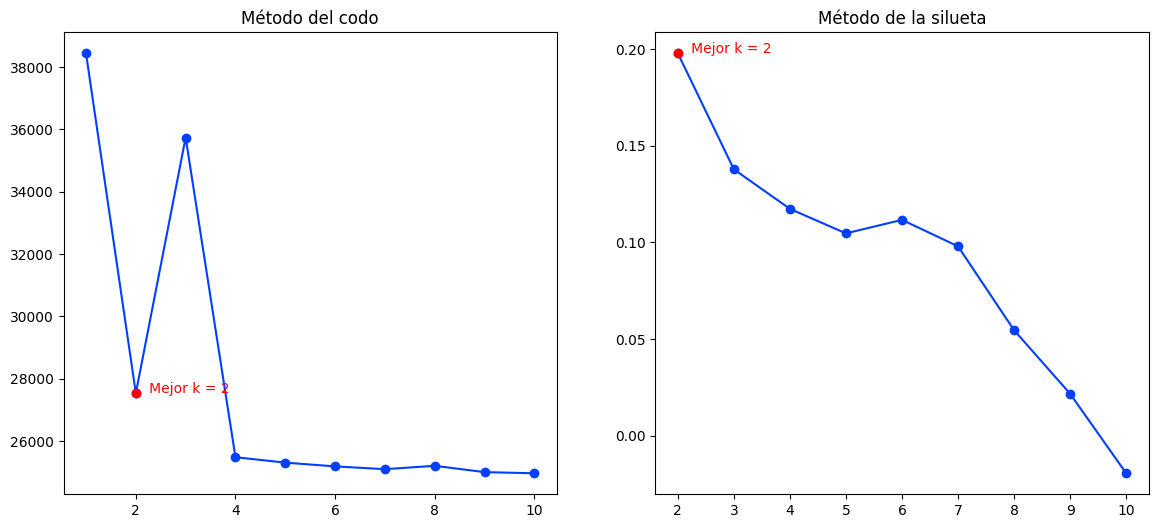

Usando = ('BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction')


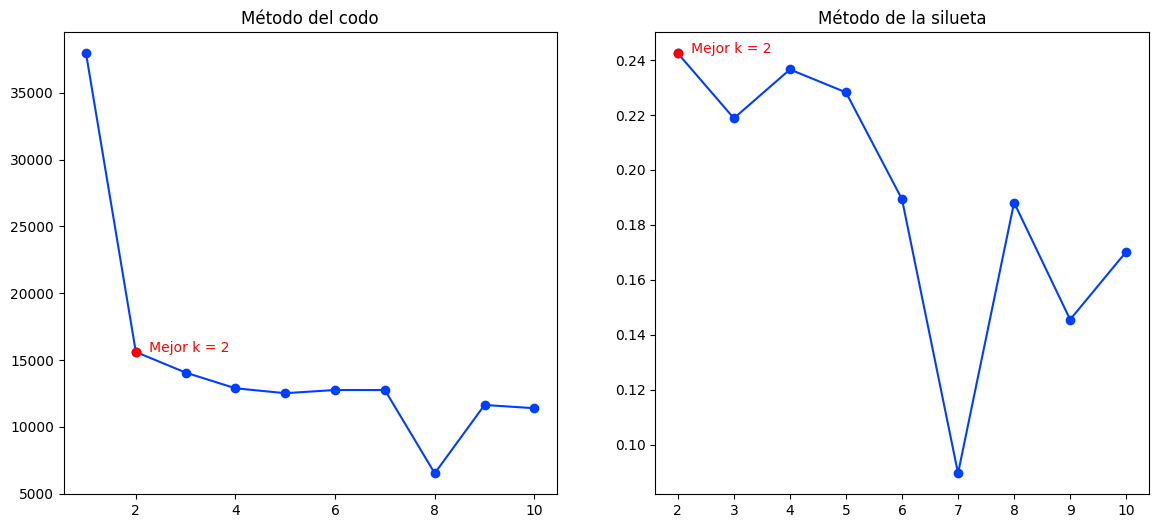

Usando = ('BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age')


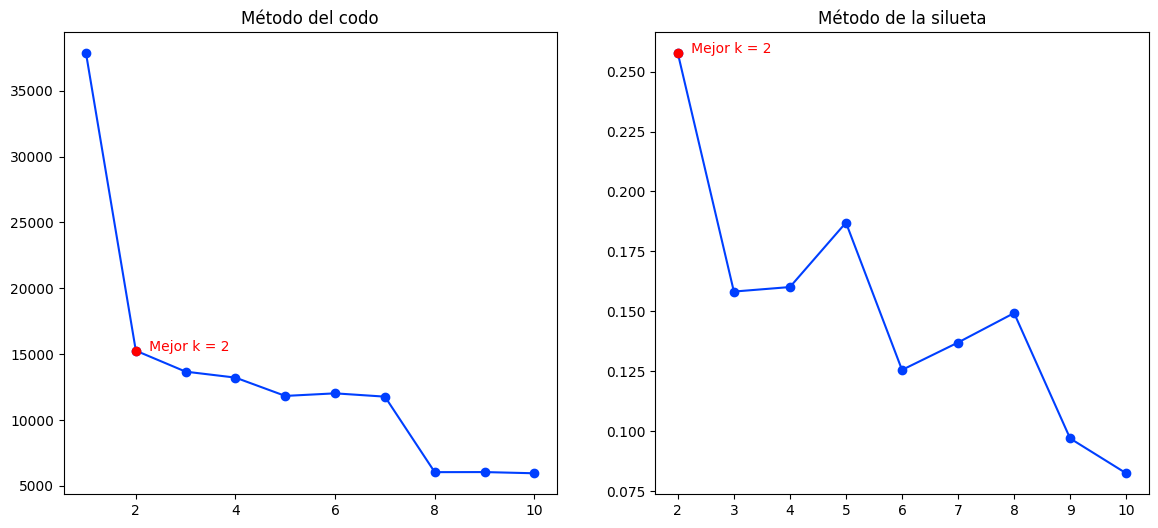

Usando = ('BloodPressure', 'SkinThickness', 'Insulin', 'DiabetesPedigreeFunction', 'Age')


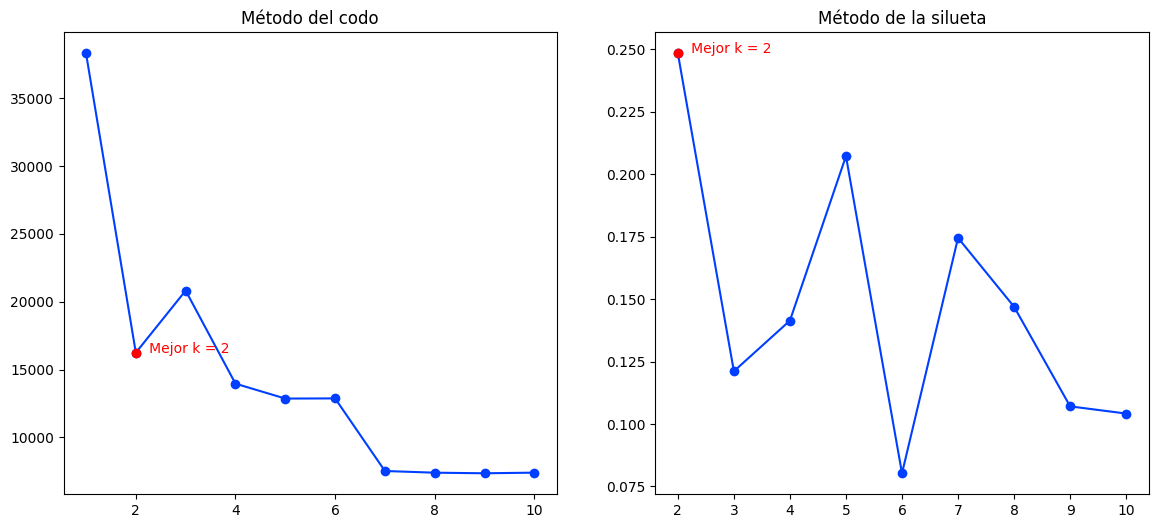

Usando = ('BloodPressure', 'SkinThickness', 'BMI', 'DiabetesPedigreeFunction', 'Age')


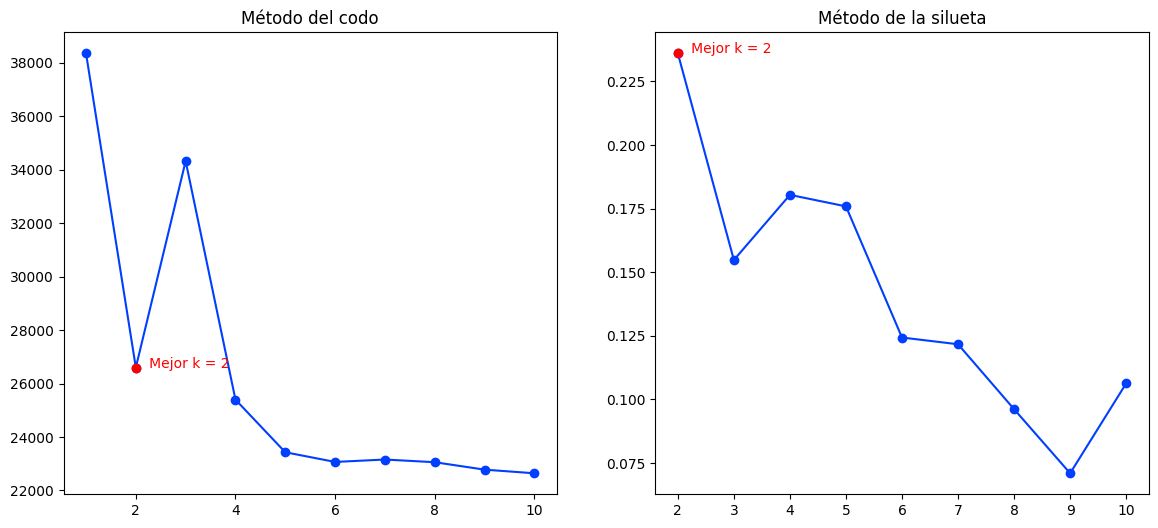

Usando = ('SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age')


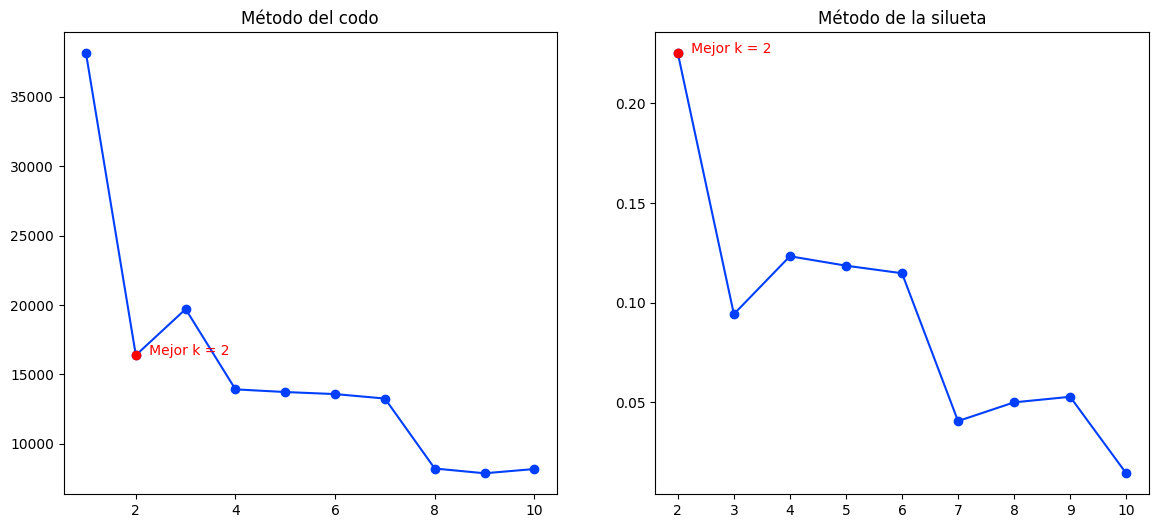

Usando = ('Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI')


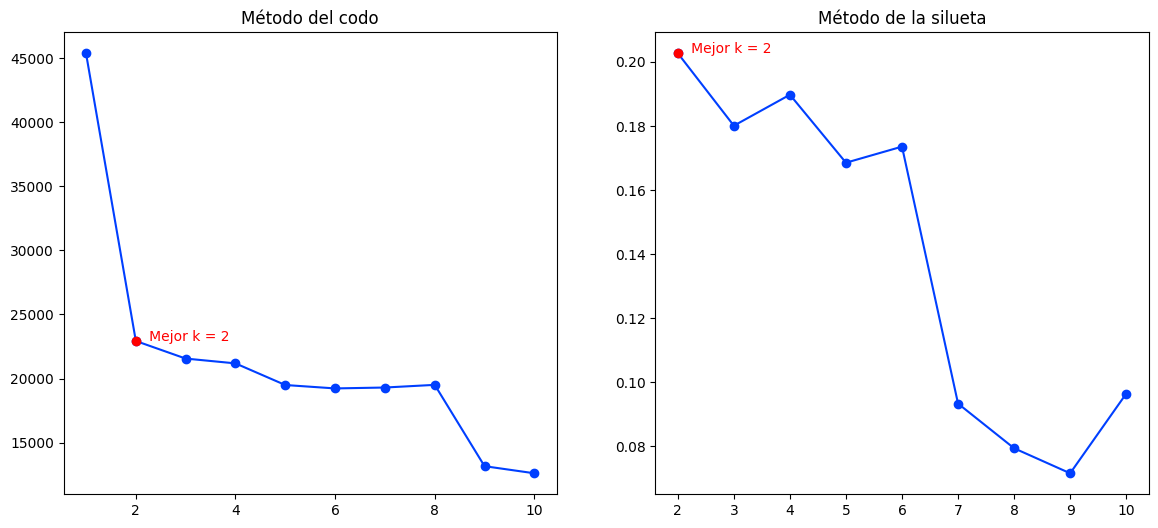

Usando = ('Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'BMI', 'DiabetesPedigreeFunction')


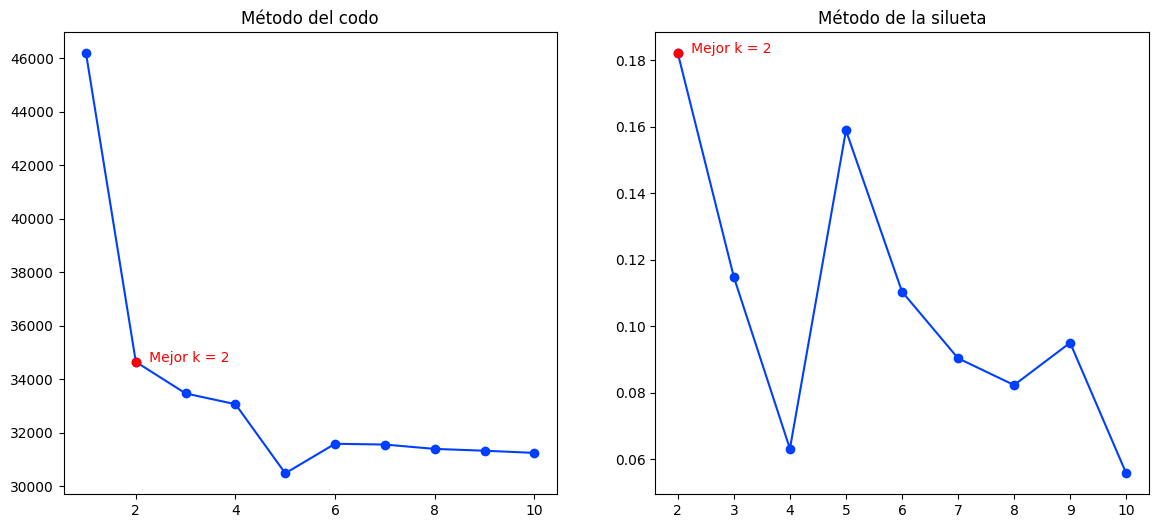

Usando = ('Pregnancies', 'Glucose', 'BloodPressure', 'Insulin', 'BMI', 'DiabetesPedigreeFunction')


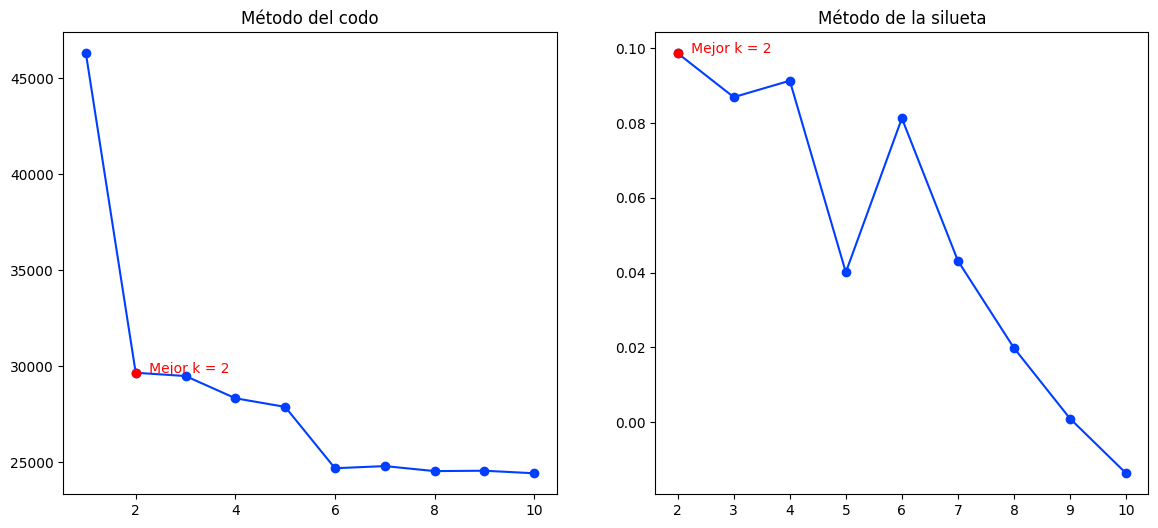

Usando = ('Pregnancies', 'Glucose', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction')


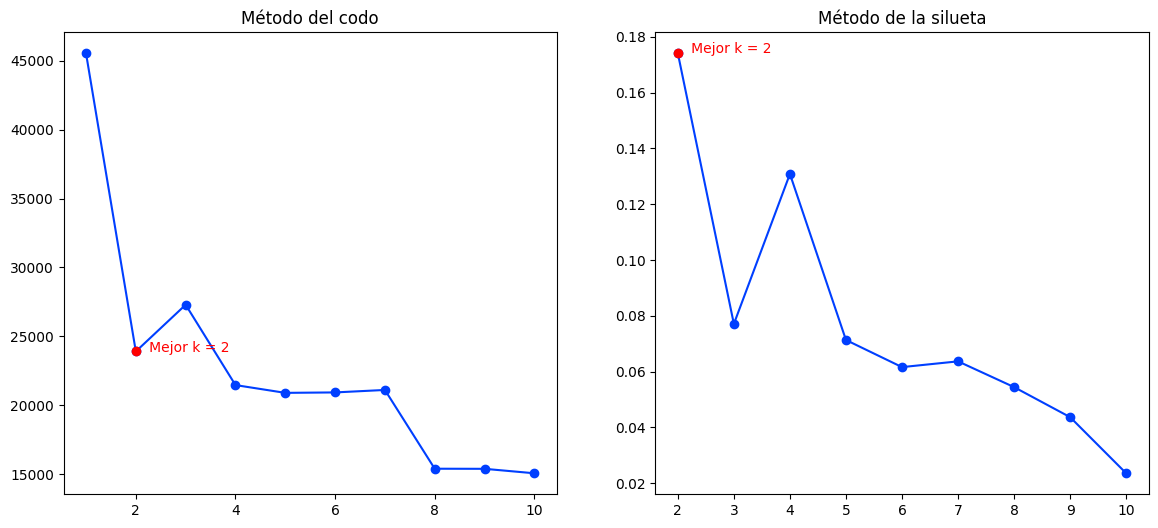

Usando = ('Pregnancies', 'Glucose', 'SkinThickness', 'Insulin', 'BMI', 'Age')


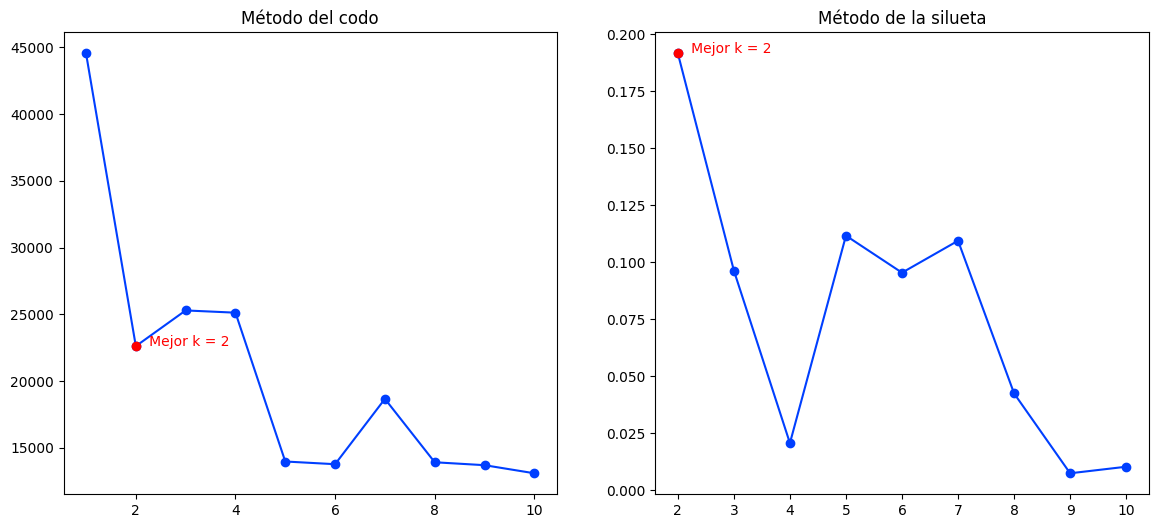

Usando = ('Pregnancies', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction')


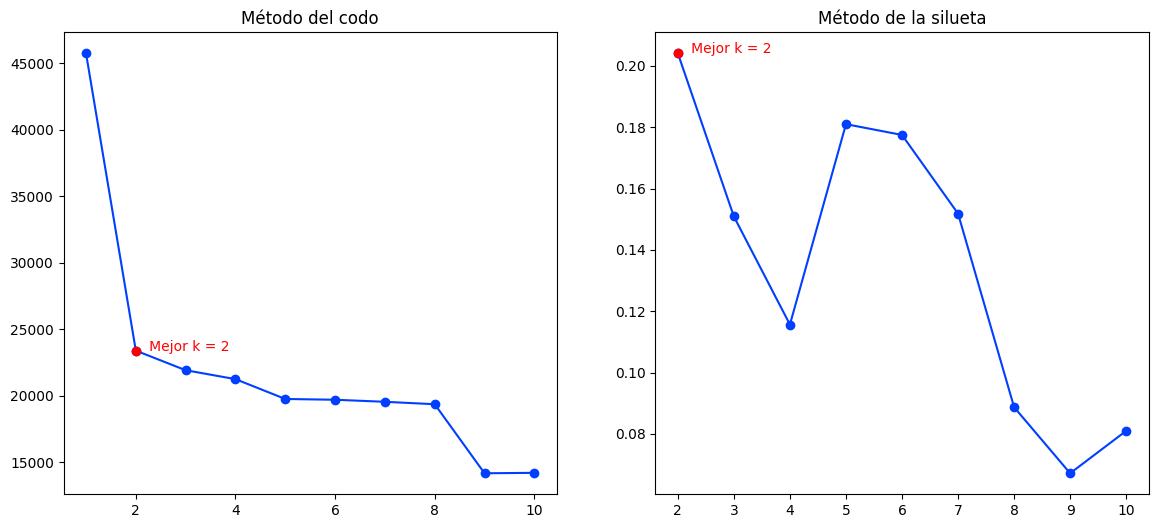

Usando = ('Pregnancies', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age')


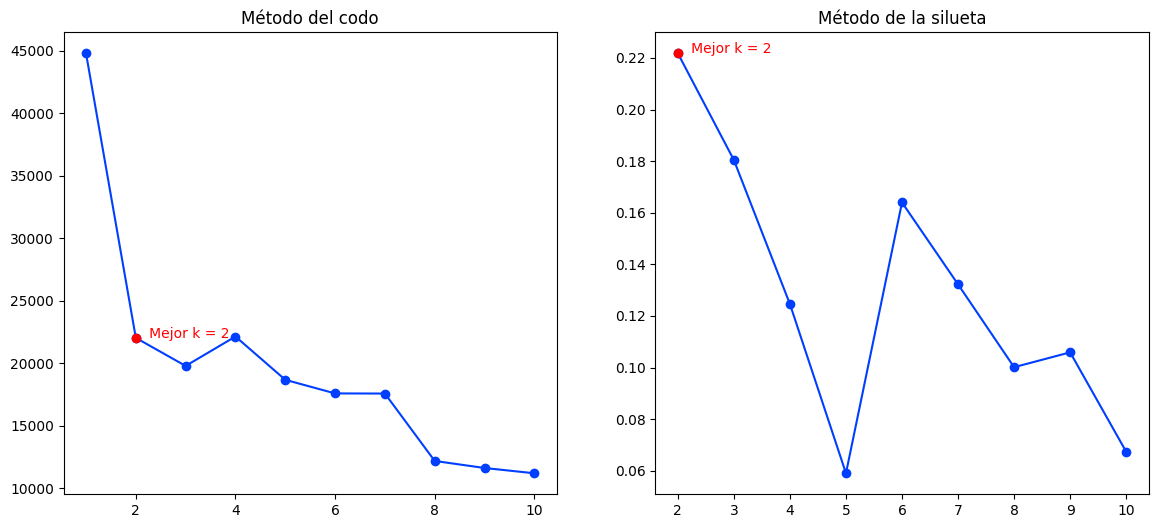

Usando = ('Pregnancies', 'BloodPressure', 'SkinThickness', 'BMI', 'DiabetesPedigreeFunction', 'Age')


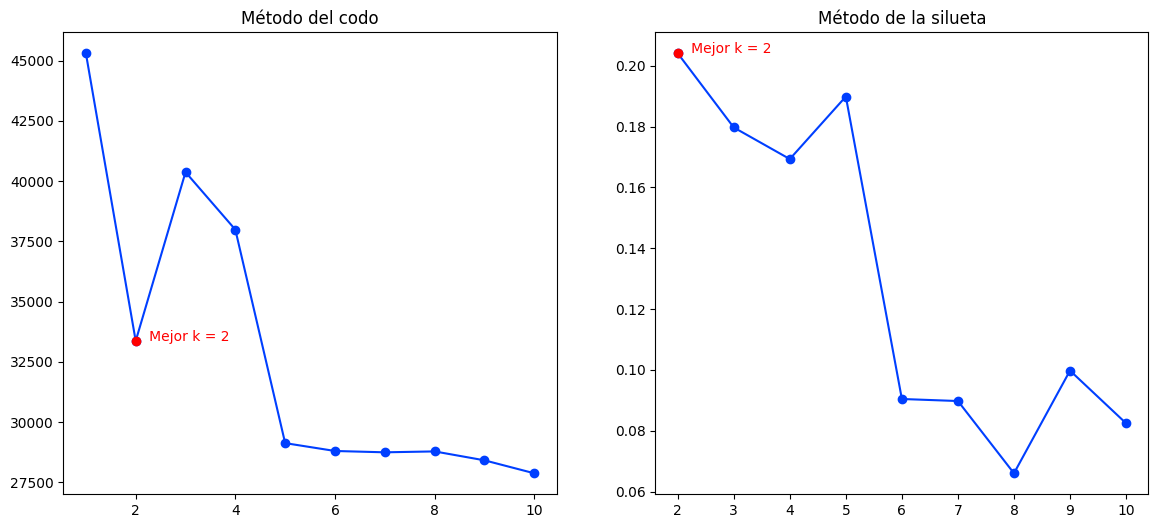

Usando = ('Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction')


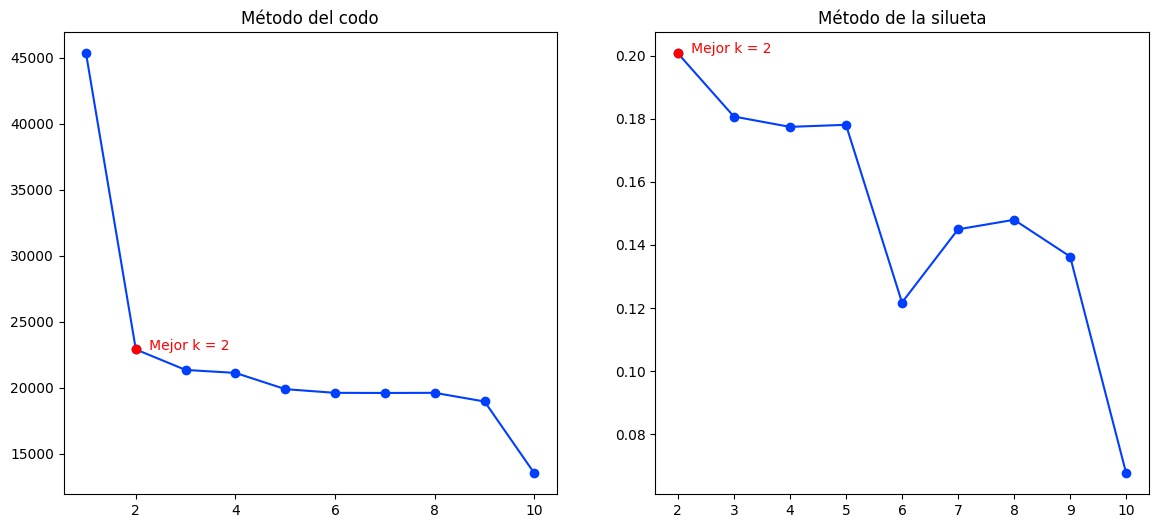

Usando = ('Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'Age')


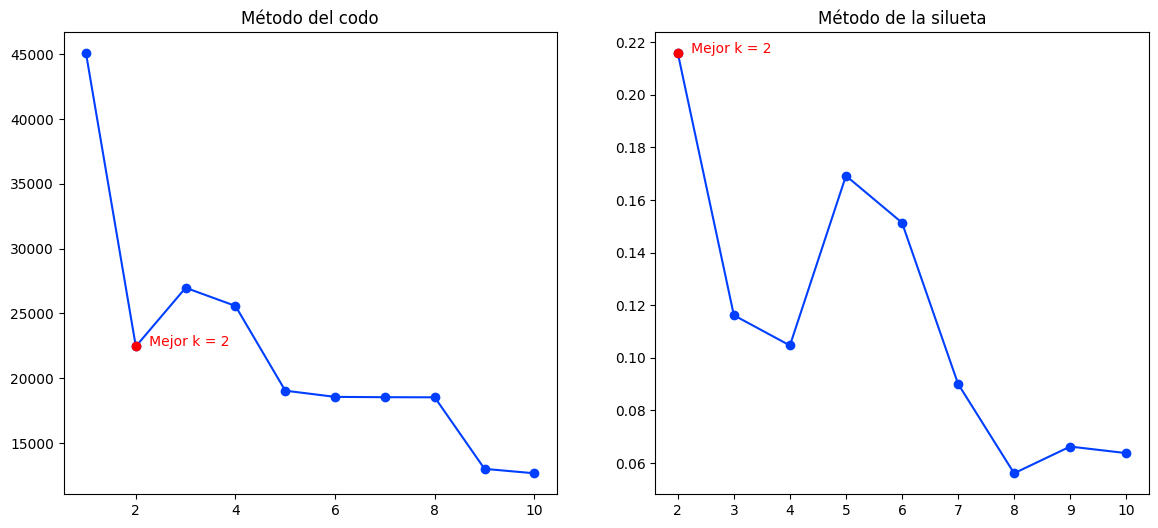

Usando = ('Glucose', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age')


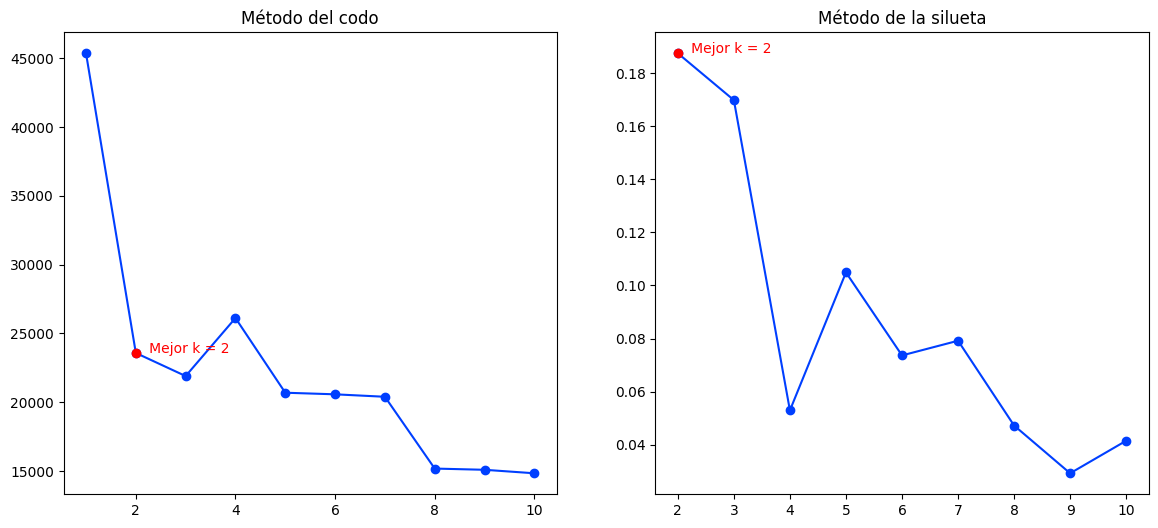

Usando = ('BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age')


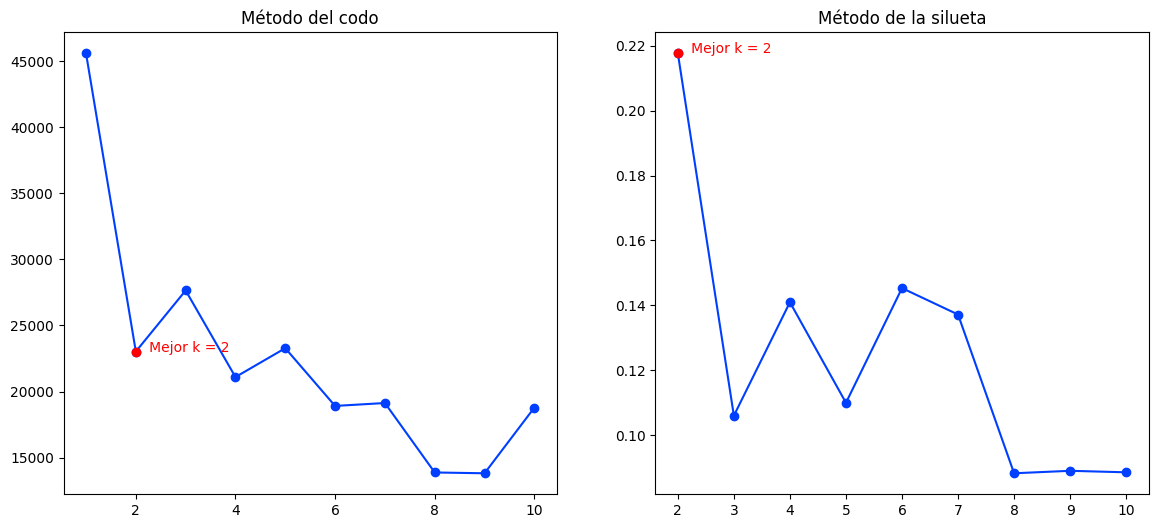

Usando = ('Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction')


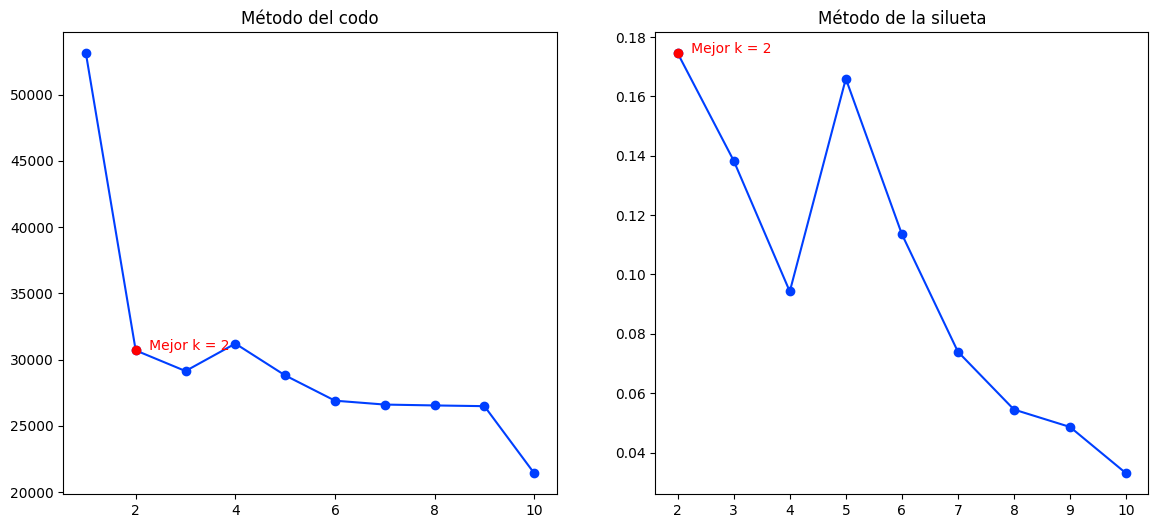

Usando = ('Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age')


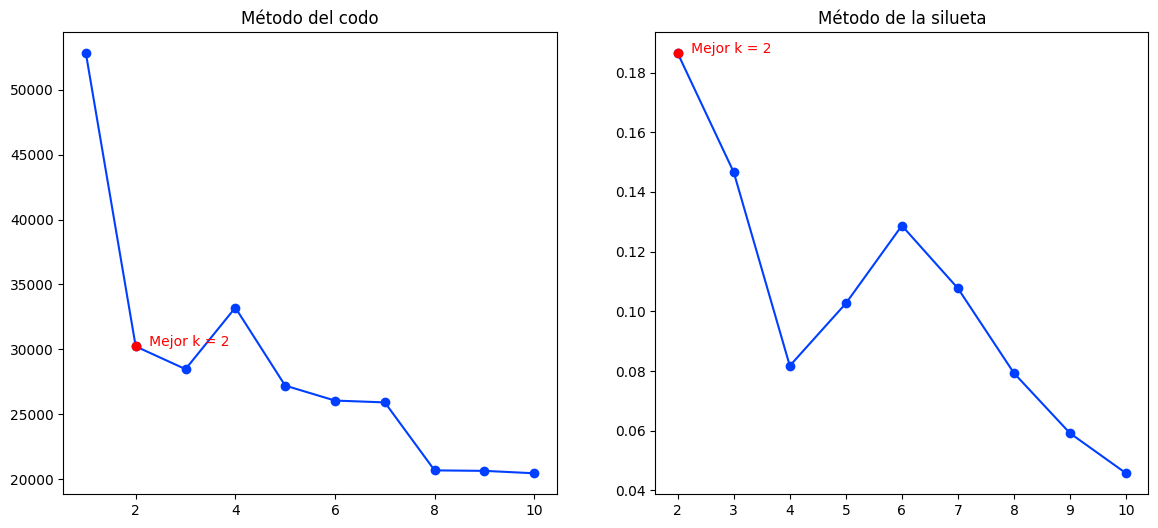

Usando = ('Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age')


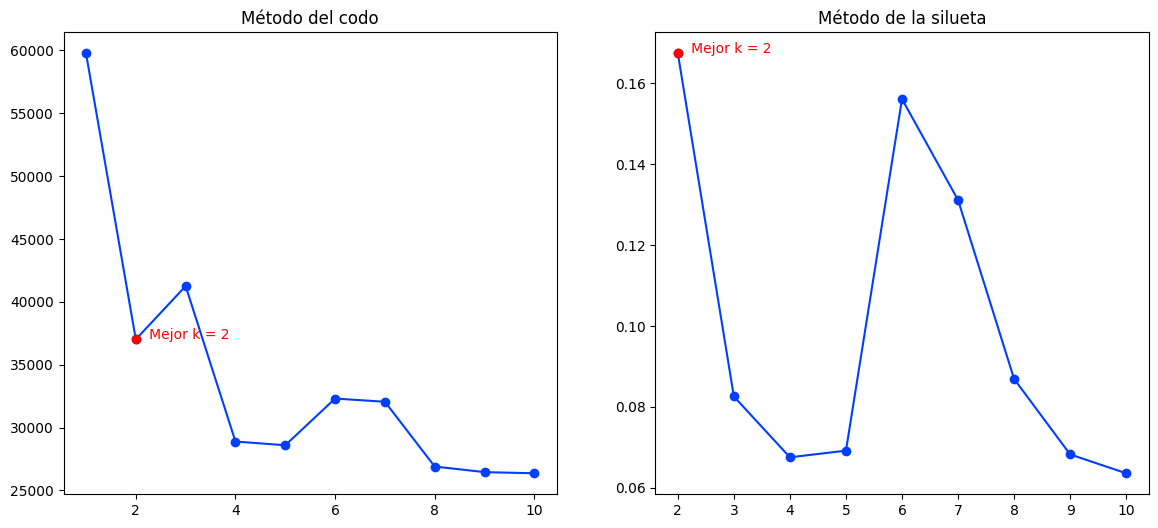

In [ ]:
plt.style.use("seaborn-v0_8-bright")

k2_cols = []
for cols in tqdm(col_combinations, total=len(col_combinations)):
    X_ = scaled.loc[:, list(cols)] # Usar datos escalados (distribución gaussiana)

    bics = [] # Criterio de información bayesiana
    silhouette_coefficients = []

    gmm = GaussianMixture(n_components=1, random_state=42)
    gmm.fit(X_)
    bics.append(gmm.bic(X_))

    for k in range(2, 11):
        gmm = GaussianMixture(n_components=k, random_state=42)
        gmm.fit(X_)
        bics.append(gmm.bic(X_))
        score = silhouette_score(X_, gmm.predict(X_))
        silhouette_coefficients.append(score)

    best_k_elbow = KneeLocator(range(1, 11), bics, curve="convex", direction="decreasing").elbow # Mejor k con método del codo
    best_k_sil = max(enumerate(silhouette_coefficients, start=2), key=lambda x: x[1])[0] # Mejor K con método de la silueta

    if not (best_k_elbow == best_k_sil == 2): continue # Ignorar combinación de columnas si no cumplen con la k deseada
    k2_cols.append(cols) # Añadir combinación de columnas que cumplen con el criterio

    # Visualización
    print(f'Usando = {cols}')
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    axes[0].plot(range(1, 11), bics, marker='o')
    axes[0].plot(best_k_elbow, bics[best_k_elbow - 1], marker='o', color='red')
    axes[0].text(best_k_elbow, bics[best_k_elbow - 1], '   Mejor k = ' + str(best_k_elbow), color='red')
    plt.xticks(range(1, 11))
    axes[0].set_title('Método del codo')

    axes[1].plot(range(2, 11), silhouette_coefficients, marker='o')
    axes[1].plot(best_k_sil, silhouette_coefficients[best_k_sil - 2], marker='o', color='red')
    axes[1].text(best_k_sil, silhouette_coefficients[best_k_sil - 2], '   Mejor k = ' + str(best_k_sil), color='red')
    plt.xticks(range(2, 11))
    axes[1].set_title('Método de la silueta')

    plt.show()

#### Entrenamiento

In [ ]:
cols = ('Pregnancies', 'Glucose', 'SkinThickness') # Combinación de columnas arbitrariamente extraída de 'k2_cols'
X_ = scaled.loc[:, cols]

gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(X_)

pred_labels = gmm.predict(X_)
evaluate(y, pred_labels, str(cols) + '\t ---')

('Pregnancies', 'Glucose', 'SkinThickness')	 ---	 Accuracy = 58.74%    	 F1 Score = 34.82%


#### Visualización

              precision    recall  f1-score   support

           0       0.67      0.73      0.70      1816
           1       0.38      0.32      0.35       952

    accuracy                           0.59      2768
   macro avg       0.53      0.52      0.52      2768
weighted avg       0.57      0.59      0.58      2768



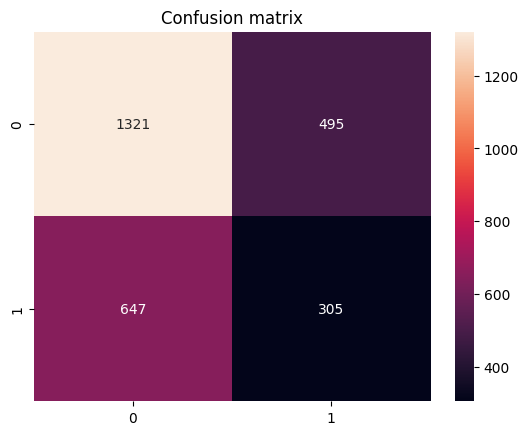

In [ ]:
visualize_metrics(y, pred_labels)